# Проект: предсказание возраста посетителей сайтов
### Задача:  

Нам необходимо построить модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст. Результат модели станет основой для реализации замыслов маркетологов о том, чтобы показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.

### Данные

Данные представлены в нескольких CSV-файлах. Они получены из разных источников. 
Вам предстоит проанализировать все доступные датафреймы, собрать их в единую таблицу и построить модель с максимально полным набором признаков. Этот базовый классификатор послужит точкой отсчёта, с которой вы будете сравнивать более тонко настроенные модели.

#### Таблица `users`
  
- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:
- `0`: младше 18;
- `1`: 18-25 лет;
- `2`: 26-40 лет;
- `3`: 41-55 лет;
- `4`: 56+ лет. 

#### Таблица `visits`

- `date` — дата посещения сайта.  
- `daytime` — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.  
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.  
- `user_id` — уникальный идентификатор пользователя.  
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

#### Таблица `ads_activity`
- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.
  
#### Таблица `surf_depth`
- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.
  
#### Таблица `primary_device`
- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

#### Таблица `cloud_usage`

- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.


## Подготовка среды и библиотек

### Загрузка и импорт библиотек

In [1]:
# Загружаем библиотеки
! pip install phik -q
! pip install category-encoders -q

In [2]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, SequentialFeatureSelector, RFE
from sklearn.metrics import f1_score, classification_report, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.impute import SimpleImputer
from tqdm import tqdm
import joblib
import dill
pd.set_option('display.max_colwidth', None)
pd.options.mode.chained_assignment = None

RANDOM_SEED=42

In [3]:
! pip freeze > requirements.txt

### Загружаем датасеты

In [4]:
# Загружаем данные
users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

In [5]:
name_datasets = [users, visits, ads_activity, surf_depth, primary_device, cloud_usage]

**Промежуточный вывод**  
- Все необходимые библиотке загружены и импортированы.
- Датасеты загружены в переменные

## Исследовательский анализ данных

### Первичная информация о таблицах

На данный момент мы имеем 6 датасетов. Напишем цикл для более подробного изучения каждого из них.

In [6]:
for name in name_datasets:
    print('========Характеристика датасета===========' )
    display(name.head(5))
    print(name.info())
    print('Количество явных дубликатов', name.duplicated().sum())
    print('Количество неявных дубликатов', name.duplicated(subset = 'user_id').sum())
    print('Пропущенные значения', name.isnull().mean())
    print('  '*100)

========Характеристика датасета===========


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB
None
Количество явных дубликатов 87
Количество неявных дубликатов 87
Пропущенные значения user_id         0.0
age_category    0.0
dtype: float64
                                                                                                                                                                                                        
========Характеристика датасета===========


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB
None
Количество явных дубликатов 15750
Количество неявных дубликатов 1059919
Пропущенные значения date                0.0
daytime             0.0
session_id          0.0
user_id             0.0
website_category    0.0
dtype: float64
                                                                                                                                                                                                        
========Характеристика датасета===========


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB
None
Количество явных дубликатов 0
Количество неявных дубликатов 0
Пропущенные значения user_id       0.0
surf_depth    0.0
dtype: float64
                                                                                                                                                                                                        
========Характеристика датасета===========


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB
None
Количество явных дубликатов 0
Количество неявных дубликатов 0
Пропущенные значения user_id           0.0
primary_device    0.0
dtype: float64
                                                                                                                                                                                                        
========Характеристика датасета===========


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.1+ KB
None
Количество явных дубликатов 0
Количество неявных дубликатов 0
Пропущенные значения user_id        0.0
cloud_usage    0.0
dtype: float64
                                                                                                                                                                                                        


**Промежуточный вывод**

- В ходе предварительного анализа данных, можно сказать, что нам представлено 6 таблиц. В 5 из них поле с идентификатором пользователя является первичным ключем. 
- Таблица `visits` содержит более 1065745 объектов, на каждого пользователя приходится несколько посещений, соответственно перед объединением необходимо будет сгруппировать поля по `user_id`, а признаки агрегировать.
- В таблице visits поле date представлена как `object`
- Пропуски в данных отсутствуют
- Таблицы были проанализированы на наличие явных и неявных дубликатов. Неявные дубликаты выявлялись по идентификатору пользователя `user_id`. В таблицах users и ads_activity число явных и неявных дубликатов совпадает, следовательно неявные дубликаты отсутствуют. В таблице visits, количество дубликатов по user_id существенно больше, что вполне очевидно. Поэтому в каждой из этих таблиц удаляем явные дубликаты.

In [7]:
#Считаем исходно количество строк
users_shape = users.shape[0]
visits_shape = visits.shape[0]
ads_activity_shape = ads_activity.shape[0]
surf_depth_shape = surf_depth.shape[0]
primary_device_shape = primary_device.shape[0]
cloud_usage_shape = cloud_usage.shape[0]

#Удаляем явные дубликаты
users = users.drop_duplicates()
visits = visits.drop_duplicates()
ads_activity = ads_activity.drop_duplicates()
surf_depth = surf_depth.drop_duplicates()
primary_device = primary_device.drop_duplicates()
cloud_usage = cloud_usage.drop_duplicates()

#Выводим статистику по удаленным данным
print('Удалено дубликатов в users:', users_shape - users.shape[0])
print('Удалено дубликатов в visits:', visits_shape - visits.shape[0])
print('Удалено дубликатов в ads_activity:', ads_activity_shape - ads_activity.shape[0])
print('Удалено дубликатов в surf_depth:', surf_depth_shape - surf_depth.shape[0])
print('Удалено дубликатов в primary_device:', primary_device_shape - primary_device.shape[0])
print('Удалено дубликатов в cloud_usage:', cloud_usage_shape - cloud_usage.shape[0])

Удалено дубликатов в users: 87
Удалено дубликатов в visits: 15750
Удалено дубликатов в ads_activity: 233
Удалено дубликатов в surf_depth: 0
Удалено дубликатов в primary_device: 0
Удалено дубликатов в cloud_usage: 0


### Изучение таблицы `visits`

Подробно изучим таблицу visits. Для того, чтобы можно было присоединить её к остальным таблицам, необходимо сгруппировать данные по идентификатору пользователя с аггрегацией данных. 

In [8]:
visits.head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [9]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1049995 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1049995 non-null  object
 1   daytime           1049995 non-null  object
 2   session_id        1049995 non-null  object
 3   user_id           1049995 non-null  object
 4   website_category  1049995 non-null  object
dtypes: object(5)
memory usage: 48.1+ MB


In [10]:
for column in visits.columns:
        print(f'Уникальные значения в {column}:')
        print(visits[column].unique())
        print(f'Количество уникальных значений в {column}:')
        print(visits[column].nunique())

Уникальные значения в date:
['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']
Количество уникальных значений в date:
14
Уникальные значения в daytime:
['вечер' 'день' 'ночь' 'утро']
Количество уникальных значений в daytime:
4
Уникальные значения в session_id:
['066e4e02-8c1f-45eb-a50f-178659abe698'
 '0bce1749-3376-439c-9a22-f8ffbba00e9a'
 '3445d8c4-221d-4d88-bb6a-a2939fe3c610' ...
 '98c0ab10-e85f-4c5b-9e41-1171bc118ac5'
 '9c25daac-741f-4cd3-9dea-31dc187957cd'
 'f3c9373d-5b8e-499d-b0ad-6f6aa76197bc']
Количество уникальных значений в session_id:
1049995
Уникальные значения в user_id:
['0010-5cf8f6b38a7b6c70a021-009dbcda' '0013-4ae5f7d127b91a3fb0f8-ba59f141'
 '0014-d3032d60979a8d2b3077-f09bdce8' ...
 'c469-75c41391dde116026e2f-b3fd02ed' '69fc-91b7925e4e9c3a31b3d9-d0709a75'
 '11b8-6ef3243269c07b120b08-abf1c504']
Количество уникальных значений в user_id:
58

### Создание новых признаков

Качество моделей во многом зависит от того, какие новые признаки будут созданы на основе исходных данных. Для этого ответим на вопросы с последующим созданием новых признаков:  
- Какая доля интернет-активности приходится на посещение сайтов разных категорий.

- Среднее количество сессий пользователя в день;

- Наиболее активное время суток у пользователя;

- Какая доля интернет-активности приходится на разное время суток.

In [11]:
visits['date'] = pd.to_datetime(visits['date'])
# Группируем по пользователю и категории, считаем число сессий
category_sessions = visits.groupby(['user_id', 'website_category']).size().reset_index(name='session_count')

# Общее число сессий для каждого пользователя
total_sessions = category_sessions.groupby('user_id')['session_count'].sum().reset_index()
total_sessions.rename(columns={'session_count': 'total_sessions'}, inplace=True)

# Объединяем и рассчитываем доли
category_share = category_sessions.merge(total_sessions, on='user_id')
category_share['category_share'] = category_share['session_count'] / category_share['total_sessions']


# Создаём pivot‑таблицу: категории в столбцах, доли в значениях
category_pivot = category_share.pivot_table(
    index='user_id',
    columns='website_category',
    values='category_share',
    fill_value=0
)
category_pivot.columns = [f'{col}_share' for col in category_pivot.columns]

# Число сессий по дням для каждого пользователя
daily_sessions = visits.groupby(['user_id', 'date']).size().reset_index(name='sessions_per_day')


# Среднее число сессий в день для каждого пользователя
avg_daily_sessions = daily_sessions.groupby('user_id')['sessions_per_day'].mean().reset_index()
avg_daily_sessions.rename(columns={'sessions_per_day': 'avg_daily_sessions'}, inplace=True)

# Считаем число сессий по периодам дня для каждого пользователя
time_activity = visits.groupby(['user_id', 'daytime']).size().reset_index(name='session_count')

# Находим период с максимальным числом сессий для каждого пользователя
most_active_time = time_activity.loc[
    time_activity.groupby('user_id')['session_count'].idxmax()
]
most_active_time = most_active_time[['user_id', 'daytime']]
most_active_time.rename(columns={'daytime': 'most_active_period'}, inplace=True)


# Общее число сессий для каждого пользователя (уже посчитано выше)
total_per_user = time_activity.groupby('user_id')['session_count'].sum().reset_index()
total_per_user.rename(columns={'session_count': 'total_sessions'}, inplace=True)

# Объединяем и рассчитываем доли активности по периодам
time_share = time_activity.merge(total_per_user, on='user_id')
time_share['time_share'] = time_share['session_count'] / time_share['total_sessions']

# Создаём pivot‑таблицу: периоды в столбцах, доли в значениях
time_pivot = time_share.pivot_table(
    index='user_id',
    columns='daytime',
    values='time_share',
    fill_value=0
)
time_pivot.columns = [f'{col}_share' for col in time_pivot.columns]


# Начинаем с базовых данных о пользователях
final_features = users.copy()

# Последовательно присоединяем признаки
final_features = final_features.merge(category_pivot, on='user_id', how='inner')
final_features = final_features.merge(avg_daily_sessions, on='user_id', how='inner')
final_features = final_features.merge(most_active_time, on='user_id', how='inner')
final_features = final_features.merge(time_pivot, on='user_id', how='inner')




In [12]:
final_features.head()

,user_id,age_category,Category 01_share,Category 02_share,Category 03_share,Category 04_share,Category 05_share,Category 06_share,Category 07_share,Category 08_share,...,Category 17_share,Category 18_share,Category 19_share,Category 20_share,avg_daily_sessions,most_active_period,вечер_share,день_share,ночь_share,утро_share
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,0.000000,0.048128,...,0.058824,0.069519,0.074866,0.042781,13.357143,день,0.336898,0.358289,0.074866,0.229947
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,...,0.035461,0.028369,0.035461,0.035461,10.071429,вечер,0.390071,0.340426,0.092199,0.177305
2,678b-614cd47d854b9d591db2-000b2e50,0,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,...,0.020000,0.010000,0.110000,0.060000,7.142857,вечер,0.380000,0.290000,0.130000,0.200000
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,...,0.064516,0.133065,0.036290,0.012097,17.714286,день,0.258065,0.439516,0.072581,0.229839
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,...,0.050420,0.033613,0.025210,0.058824,8.500000,вечер,0.420168,0.344538,0.075630,0.159664


### Объединение данных

In [13]:
# Выполняем объединение датафреймов
df1 = pd.merge(final_features, surf_depth, on='user_id', how='inner')
df2 = pd.merge(primary_device, cloud_usage, on='user_id', how='inner')
df3 = pd.merge(df1, df2, on='user_id', how='inner')
df = pd.merge(df3, ads_activity, on='user_id', how='inner')


In [14]:
df.head()

,user_id,age_category,Category 01_share,Category 02_share,Category 03_share,Category 04_share,Category 05_share,Category 06_share,Category 07_share,Category 08_share,...,avg_daily_sessions,most_active_period,вечер_share,день_share,ночь_share,утро_share,surf_depth,primary_device,cloud_usage,ads_activity
0,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,...,10.071429,вечер,0.390071,0.340426,0.092199,0.177305,средне,смартфон,False,умеренно
1,678b-614cd47d854b9d591db2-000b2e50,0,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,...,7.142857,вечер,0.380000,0.290000,0.130000,0.200000,средне,смартфон,False,умеренно
2,4ac0-dad169100b4a29b20818-b26ae7c5,4,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,...,17.714286,день,0.258065,0.439516,0.072581,0.229839,поверхностно,смартфон,True,редко
3,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,...,8.500000,вечер,0.420168,0.344538,0.075630,0.159664,поверхностно,смартфон,True,очень редко
4,348c-35488a73fb49d5b0449e-1920481e,0,0.080000,0.010000,0.090000,0.080000,0.010000,0.060000,0.050000,0.050000,...,7.142857,вечер,0.480000,0.270000,0.150000,0.100000,поверхностно,смартфон,False,умеренно


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5205 entries, 0 to 5204
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             5205 non-null   object 
 1   age_category        5205 non-null   int64  
 2   Category 01_share   5205 non-null   float64
 3   Category 02_share   5205 non-null   float64
 4   Category 03_share   5205 non-null   float64
 5   Category 04_share   5205 non-null   float64
 6   Category 05_share   5205 non-null   float64
 7   Category 06_share   5205 non-null   float64
 8   Category 07_share   5205 non-null   float64
 9   Category 08_share   5205 non-null   float64
 10  Category 09_share   5205 non-null   float64
 11  Category 10_share   5205 non-null   float64
 12  Category 11_share   5205 non-null   float64
 13  Category 12_share   5205 non-null   float64
 14  Category 13_share   5205 non-null   float64
 15  Category 14_share   5205 non-null   float64
 16  Catego

**Вывод по итоговому датасету**

- Объём данных: 5 205 записей (пользователей).

- Число признаков: 32 столбца.

**Типы данных:**

- float64 — 25 столбцов (доли категорий сайтов и времени суток);

- object — 5 столбцов (user_id, most_active_period, surf_depth, primary_device, ads_activity);

- int64 — 1 столбец (age_category);

- bool — 1 столбец (cloud_usage).

**Пропущенные значения:**  отсутствуют (все столбцы имеют 5 205 non‑null значений).

Потребление памяти: 1,2 МБ.

### Поиск аномалий

In [16]:
#Выводим статистику по числовым значениям.
df.describe()

,age_category,Category 01_share,Category 02_share,Category 03_share,Category 04_share,Category 05_share,Category 06_share,Category 07_share,Category 08_share,Category 09_share,...,Category 16_share,Category 17_share,Category 18_share,Category 19_share,Category 20_share,avg_daily_sessions,вечер_share,день_share,ночь_share,утро_share
count,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,...,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000,5205.000000
mean,2.433429,0.050012,0.041923,0.065265,0.048675,0.057014,0.053644,0.051668,0.052686,0.050550,...,0.043165,0.047128,0.047819,0.051910,0.048006,12.888867,0.358651,0.364471,0.078162,0.198716
std,1.384566,0.031288,0.029423,0.052210,0.028013,0.029353,0.028055,0.029343,0.032405,0.028182,...,0.028480,0.029151,0.031786,0.028804,0.029024,5.431316,0.048965,0.045274,0.024709,0.037945
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,7.142857,0.214286,0.217822,0.000000,0.049505
25%,2.000000,0.026810,0.019011,0.019802,0.029240,0.036765,0.033898,0.030000,0.028902,0.030000,...,0.021277,0.025641,0.024242,0.030303,0.026786,8.785714,0.324742,0.334365,0.060606,0.172794
50%,3.000000,0.048485,0.040000,0.060000,0.046053,0.055336,0.051136,0.050000,0.050420,0.049057,...,0.040346,0.045198,0.043956,0.050000,0.045714,11.928571,0.357955,0.364985,0.076142,0.196891
75%,4.000000,0.070000,0.061135,0.101562,0.066176,0.075630,0.070796,0.070000,0.074286,0.068376,...,0.060000,0.065217,0.068000,0.070000,0.066667,15.214286,0.391626,0.395000,0.093458,0.223529
max,4.000000,0.182927,0.180556,0.261438,0.188119,0.172131,0.171053,0.165414,0.188679,0.188034,...,0.159420,0.187970,0.195804,0.180000,0.168224,59.928571,0.530000,0.532710,0.198020,0.339623


**Промежуточный вывод по выбросам**

Аномальный значений обнаружено не было. Вопросы вызывает лишь признак со средним числом посещений сайта в день: 60 посещений при медиане в 11?

### Анлиз целевой переменной

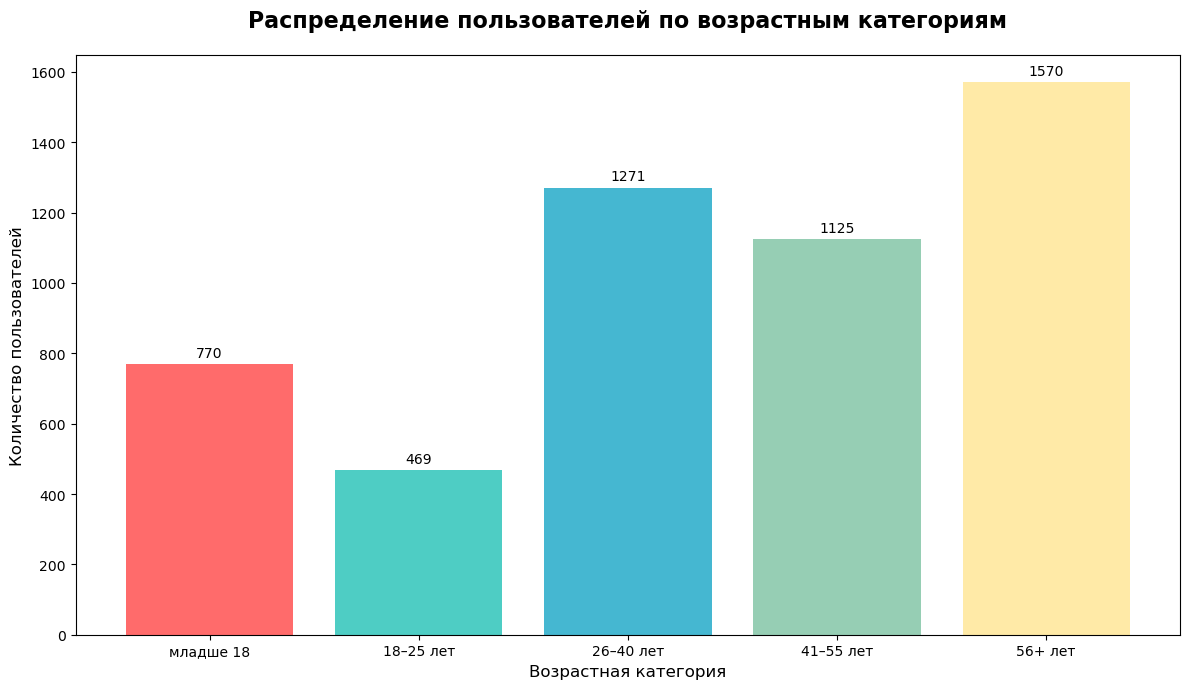

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

# Подсчёт значений
values = df['age_category'].value_counts().sort_index()

# Соответствие категорий и подписей
age_labels = {
    0: 'младше 18',
    1: '18–25 лет',
    2: '26–40 лет',
    3: '41–55 лет',
    4: '56+ лет'
}

# Создаём подписи для оси X
x_labels = [age_labels[i] for i in values.index]


# Построение графика
bars = ax.bar(x_labels, values.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])


# Оформление
ax.set_title('Распределение пользователей по возрастным категориям', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Возрастная категория', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)  # Горизонтальные подписи
plt.tight_layout()
plt.show()

**Ключевые выводы:**

- Самая многочисленная группа — пользователи 56 лет и старше (30,2 %).

- Наименее представленная группа — 18–25 лет (9 %).

- Пользователи 26–40 лет и 41–55 лет составляют около 46 % аудитории.

- Молодёжь (до 25 лет) — около 24 % пользователей.

В данных наблюдается сильный дисбаланс 

### Анализ признаков

Проанализируем каждый признак на предмет типа данных и его принадлежности к числовым или категориальным.

In [18]:
df.dtypes

user_id                object
age_category            int64
Category 01_share     float64
Category 02_share     float64
Category 03_share     float64
Category 04_share     float64
Category 05_share     float64
Category 06_share     float64
Category 07_share     float64
Category 08_share     float64
Category 09_share     float64
Category 10_share     float64
Category 11_share     float64
Category 12_share     float64
Category 13_share     float64
Category 14_share     float64
Category 15_share     float64
Category 16_share     float64
Category 17_share     float64
Category 18_share     float64
Category 19_share     float64
Category 20_share     float64
avg_daily_sessions    float64
most_active_period     object
вечер_share           float64
день_share            float64
ночь_share            float64
утро_share            float64
surf_depth             object
primary_device         object
cloud_usage              bool
ads_activity           object
dtype: object

- `user_id` - идентификатор пользователя, который в последствиии мы удалим  
- `age_category` - целевая переменная, по сути это категориальный тип. Но так как у нас задача классификации, то менять тип с int на object не требуется.  
- `category_Category 1-20` - Числовые признаки, доли.   
- `avg_daily_sessions` - также числовой признак, среднее значение.   
- `most_active_period` - категориальный тип данных, здесь все правильно.  
- `вечер_share`, `день_share`, `ночь_share`, `утро_share` - также долевой показатель.   
- `surf_depth` - категориальный признак с типом object  
- `primary_device` - категориальный признак с типом object  
- `cloud_usage` - бинарный признак  
- `ads_activity` - характеристика CTR, тип object  

In [19]:
df.columns

Index(['user_id', 'age_category', 'Category 01_share', 'Category 02_share',
       'Category 03_share', 'Category 04_share', 'Category 05_share',
       'Category 06_share', 'Category 07_share', 'Category 08_share',
       'Category 09_share', 'Category 10_share', 'Category 11_share',
       'Category 12_share', 'Category 13_share', 'Category 14_share',
       'Category 15_share', 'Category 16_share', 'Category 17_share',
       'Category 18_share', 'Category 19_share', 'Category 20_share',
       'avg_daily_sessions', 'most_active_period', 'вечер_share', 'день_share',
       'ночь_share', 'утро_share', 'surf_depth', 'primary_device',
       'cloud_usage', 'ads_activity'],
      dtype='object')

In [20]:
df['cloud_usage'] = df['cloud_usage'].astype('category')

In [21]:
num_feature = ['Category 01_share', 'Category 02_share',
       'Category 03_share', 'Category 04_share', 'Category 05_share',
       'Category 06_share', 'Category 07_share', 'Category 08_share',
       'Category 09_share', 'Category 10_share', 'Category 11_share',
       'Category 12_share', 'Category 13_share', 'Category 14_share',
       'Category 15_share', 'Category 16_share', 'Category 17_share',
       'Category 18_share', 'Category 19_share', 'Category 20_share',
       'avg_daily_sessions', 'вечер_share', 'день_share',
       'ночь_share', 'утро_share']

cat_feature = ['most_active_period', 'surf_depth', 'primary_device', 'cloud_usage', 'ads_activity']

Проанализируем числовые признаки



=== АНАЛИЗ ПРИЗНАКА: Category 01_share ===
Среднее: 0.0500
Медиана: 0.0485
Стандартное отклонение: 0.0313
Минимум: 0.0000
Максимум: 0.1829
Пропуски: 0
Выбросы (по IQR): 41


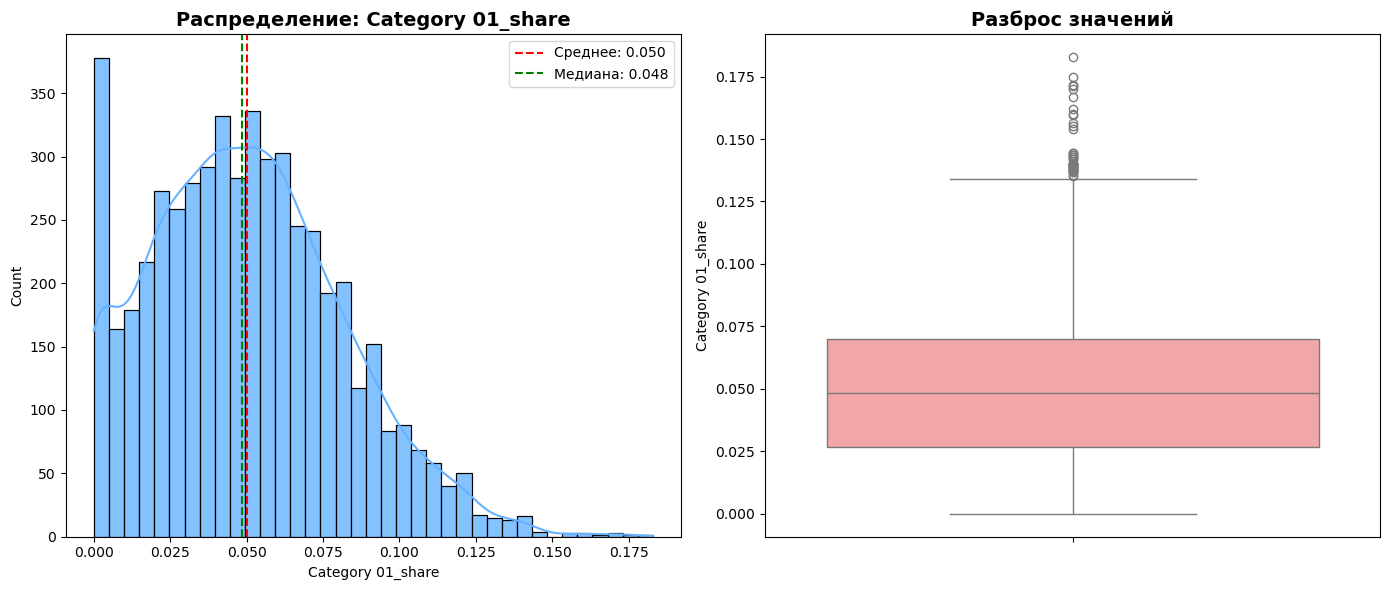


=== АНАЛИЗ ПРИЗНАКА: Category 02_share ===
Среднее: 0.0419
Медиана: 0.0400
Стандартное отклонение: 0.0294
Минимум: 0.0000
Максимум: 0.1806
Пропуски: 0
Выбросы (по IQR): 33


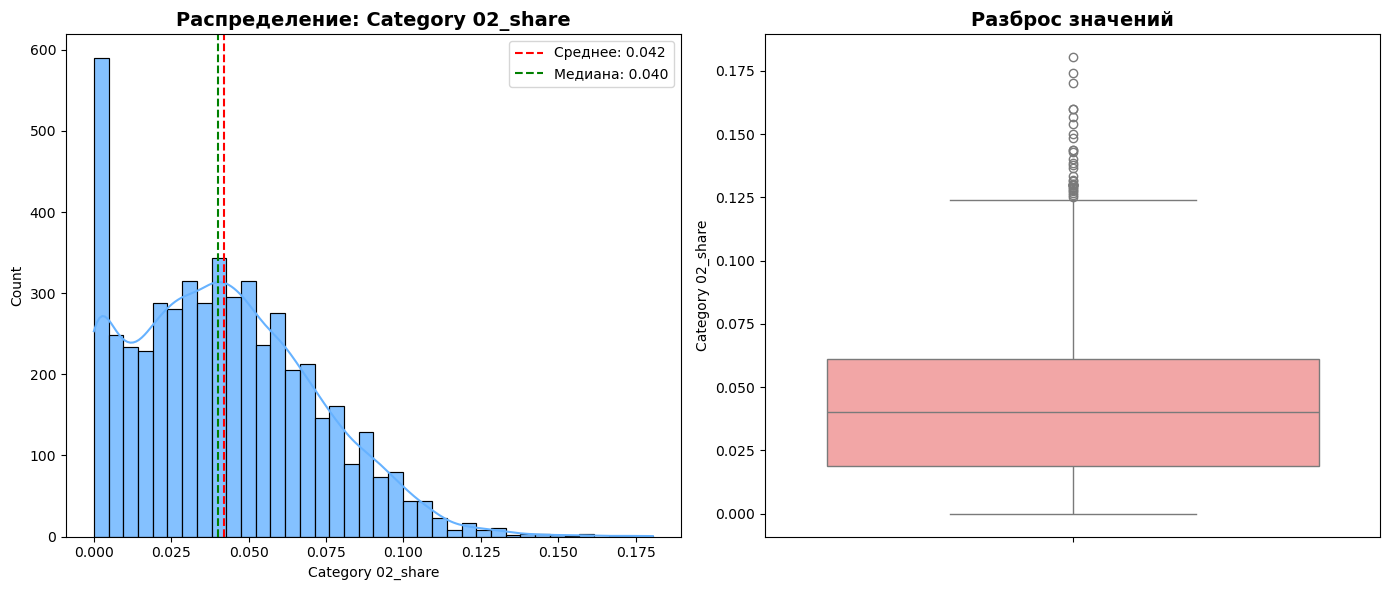


=== АНАЛИЗ ПРИЗНАКА: Category 03_share ===
Среднее: 0.0653
Медиана: 0.0600
Стандартное отклонение: 0.0522
Минимум: 0.0000
Максимум: 0.2614
Пропуски: 0
Выбросы (по IQR): 17


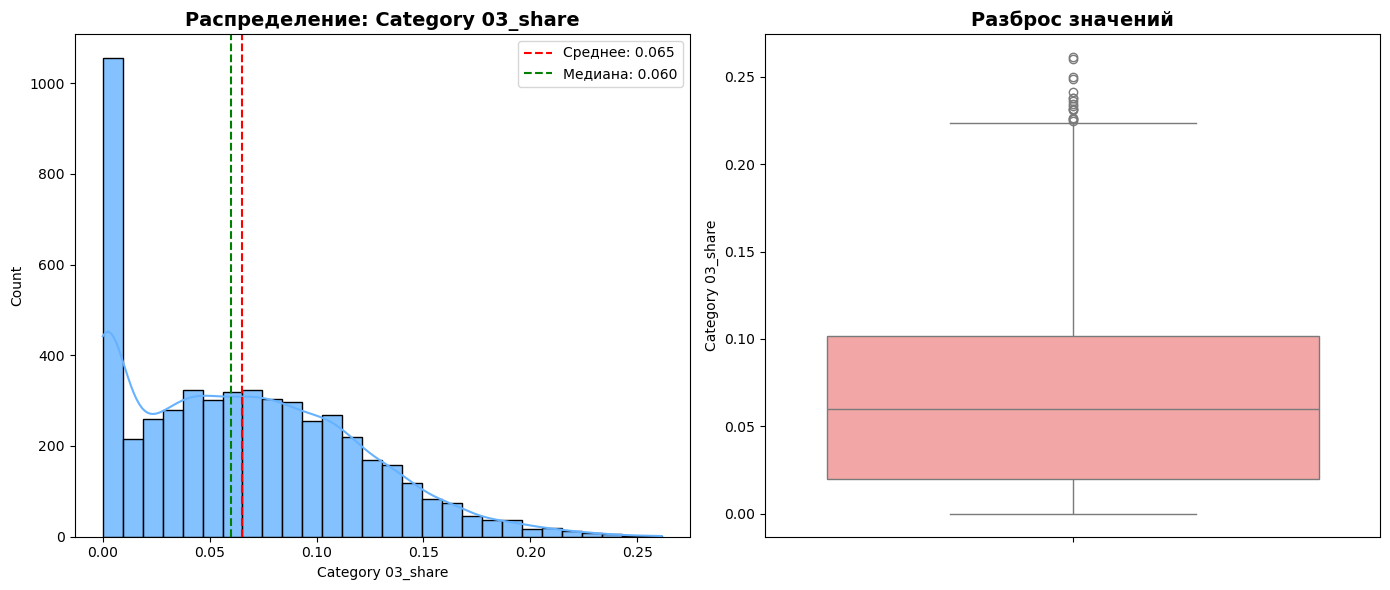


=== АНАЛИЗ ПРИЗНАКА: Category 04_share ===
Среднее: 0.0487
Медиана: 0.0461
Стандартное отклонение: 0.0280
Минимум: 0.0000
Максимум: 0.1881
Пропуски: 0
Выбросы (по IQR): 69


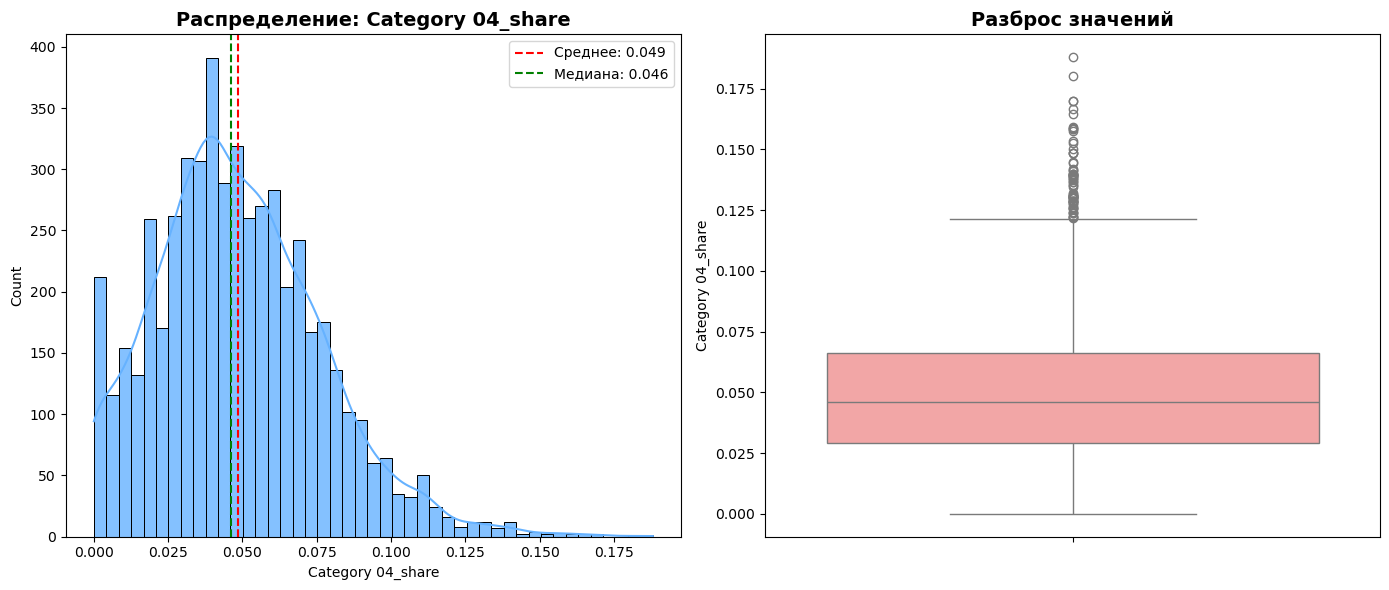


=== АНАЛИЗ ПРИЗНАКА: Category 05_share ===
Среднее: 0.0570
Медиана: 0.0553
Стандартное отклонение: 0.0294
Минимум: 0.0000
Максимум: 0.1721
Пропуски: 0
Выбросы (по IQR): 54


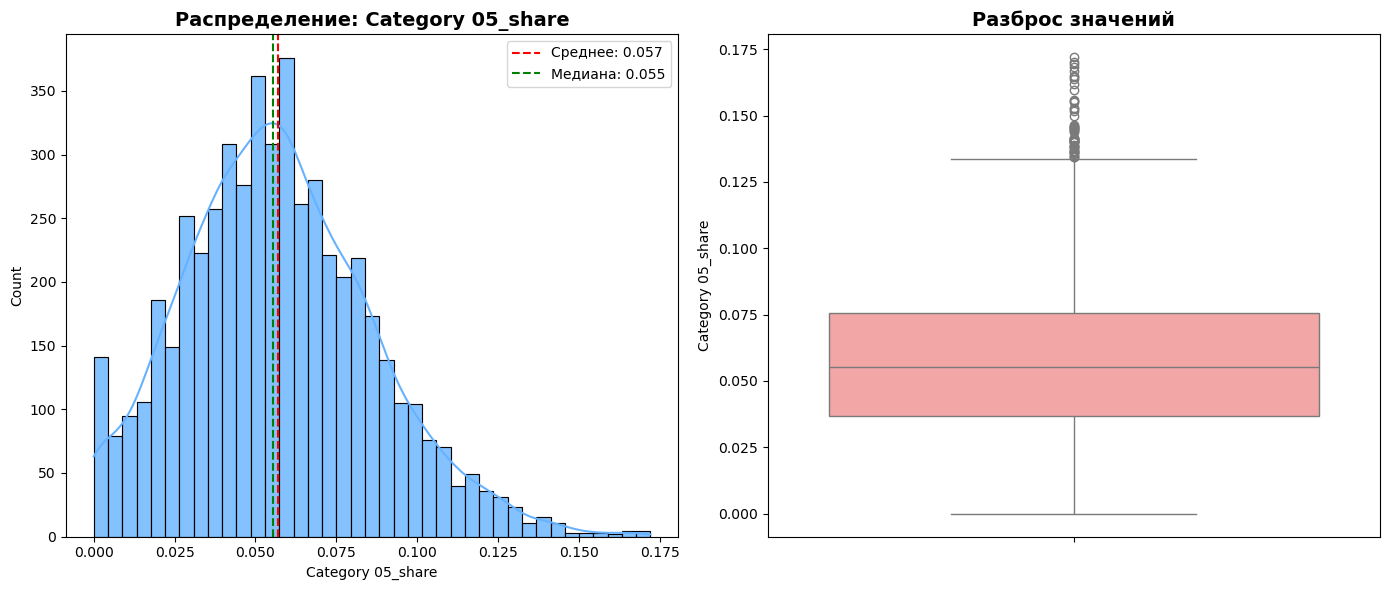


=== АНАЛИЗ ПРИЗНАКА: Category 06_share ===
Среднее: 0.0536
Медиана: 0.0511
Стандартное отклонение: 0.0281
Минимум: 0.0000
Максимум: 0.1711
Пропуски: 0
Выбросы (по IQR): 57


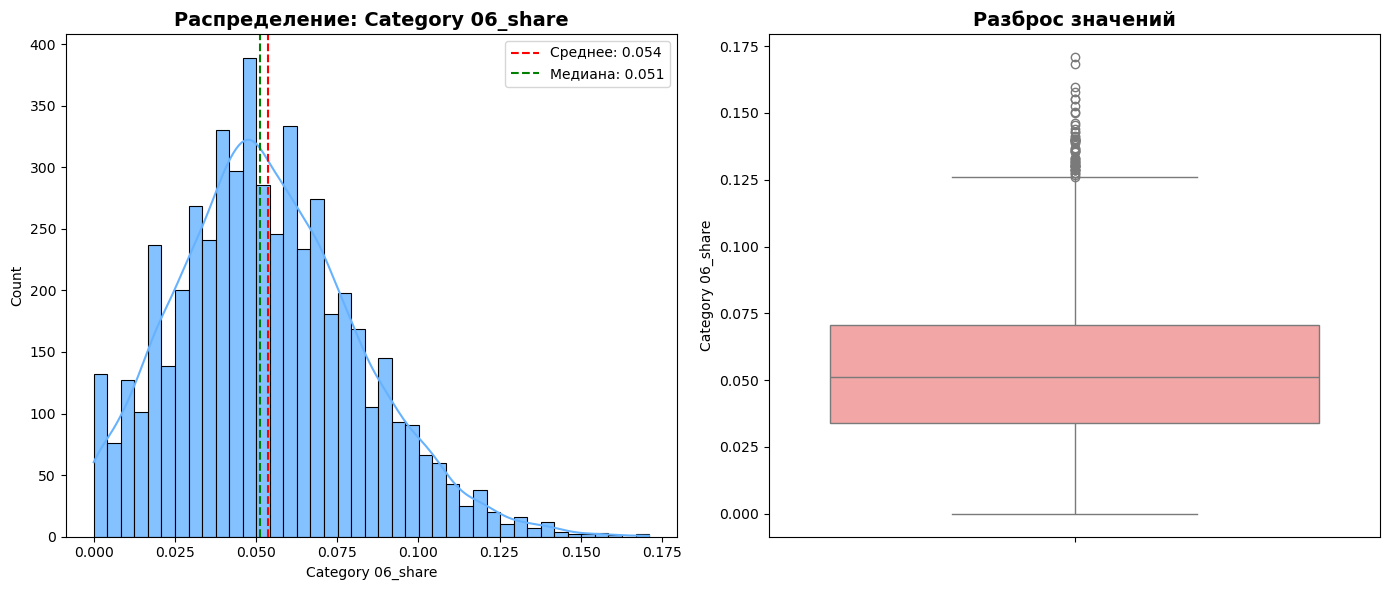


=== АНАЛИЗ ПРИЗНАКА: Category 07_share ===
Среднее: 0.0517
Медиана: 0.0500
Стандартное отклонение: 0.0293
Минимум: 0.0000
Максимум: 0.1654
Пропуски: 0
Выбросы (по IQR): 39


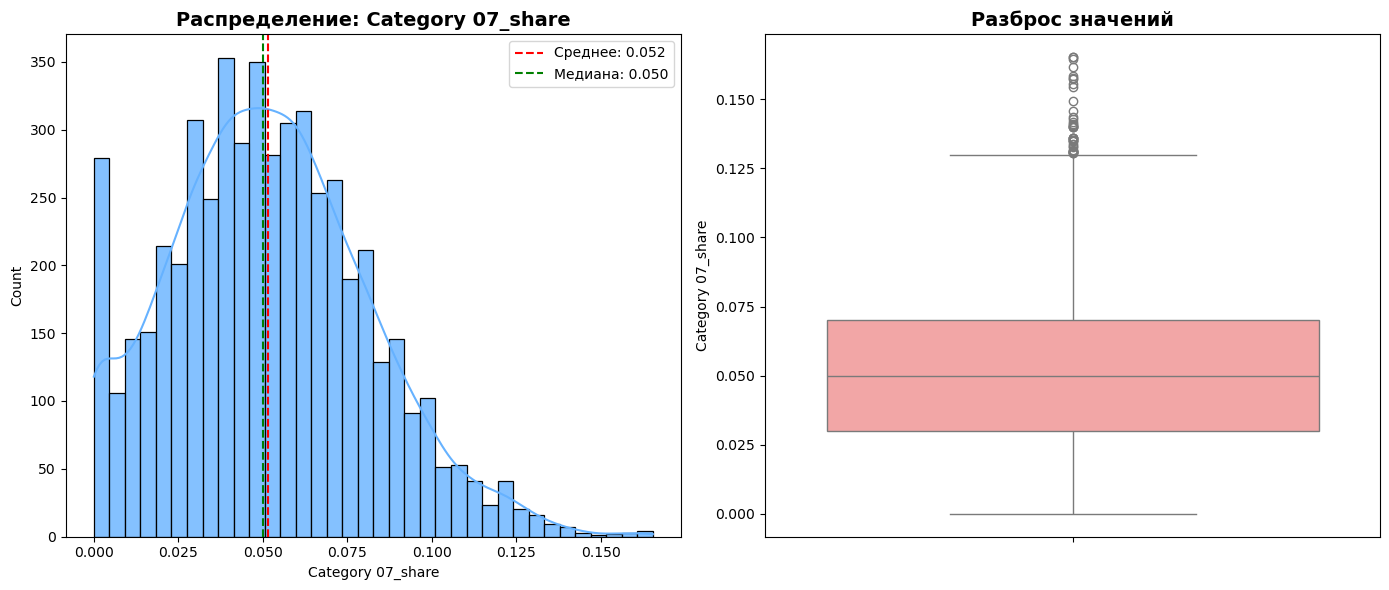


=== АНАЛИЗ ПРИЗНАКА: Category 08_share ===
Среднее: 0.0527
Медиана: 0.0504
Стандартное отклонение: 0.0324
Минимум: 0.0000
Максимум: 0.1887
Пропуски: 0
Выбросы (по IQR): 38


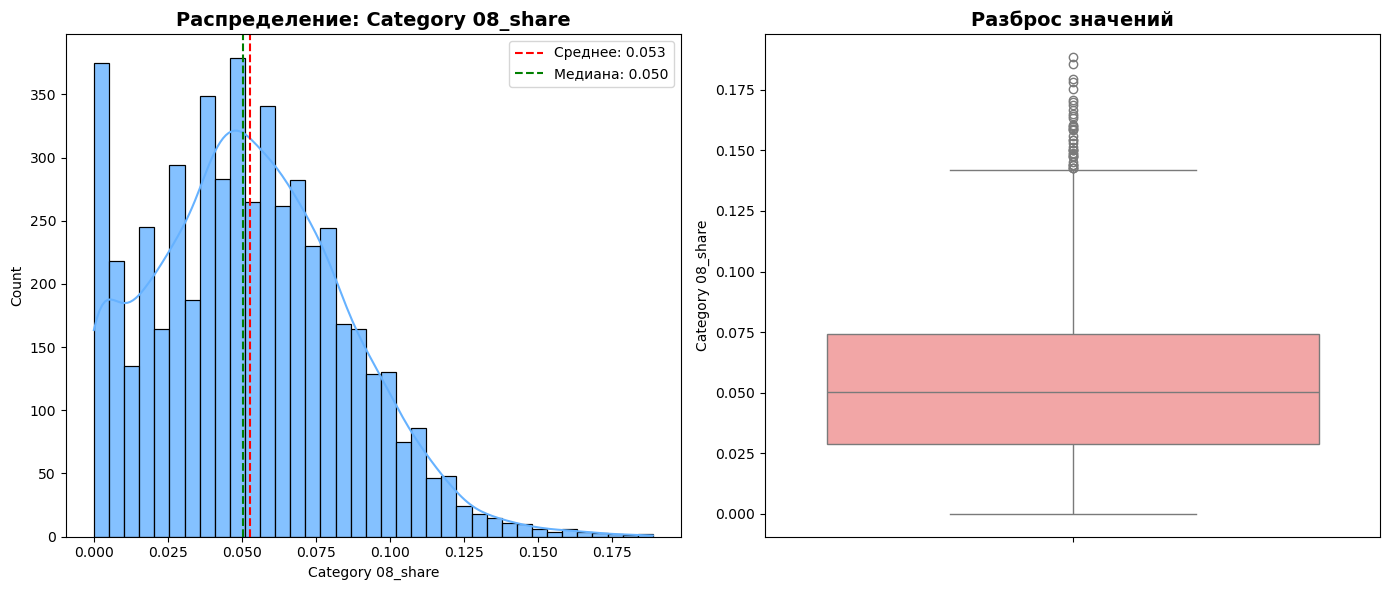


=== АНАЛИЗ ПРИЗНАКА: Category 09_share ===
Среднее: 0.0505
Медиана: 0.0491
Стандартное отклонение: 0.0282
Минимум: 0.0000
Максимум: 0.1880
Пропуски: 0
Выбросы (по IQR): 57


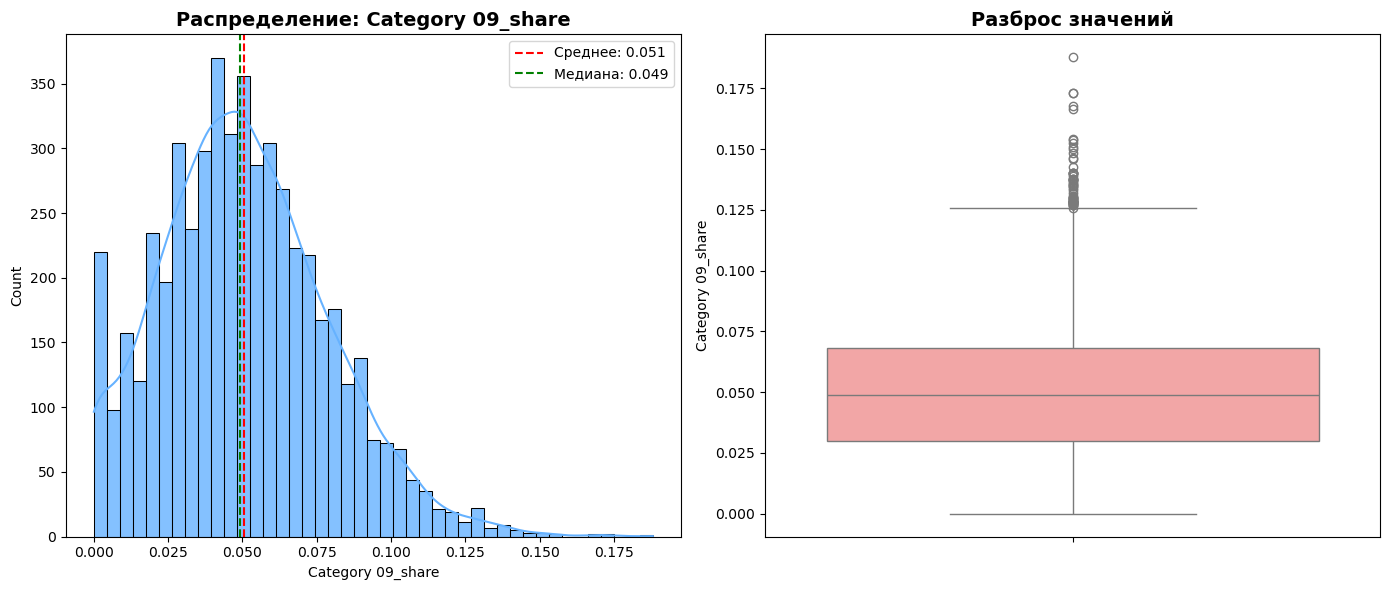


=== АНАЛИЗ ПРИЗНАКА: Category 10_share ===
Среднее: 0.0494
Медиана: 0.0476
Стандартное отклонение: 0.0287
Минимум: 0.0000
Максимум: 0.2178
Пропуски: 0
Выбросы (по IQR): 68


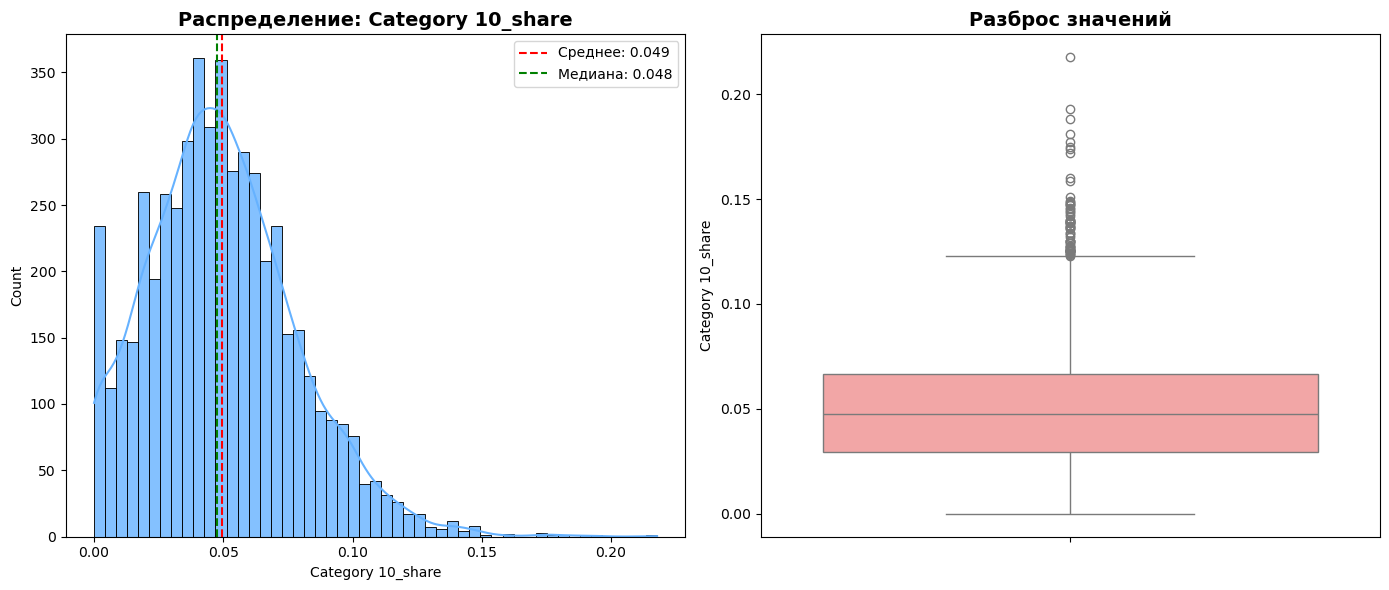


=== АНАЛИЗ ПРИЗНАКА: Category 11_share ===
Среднее: 0.0367
Медиана: 0.0333
Стандартное отклонение: 0.0270
Минимум: 0.0000
Максимум: 0.1746
Пропуски: 0
Выбросы (по IQR): 54


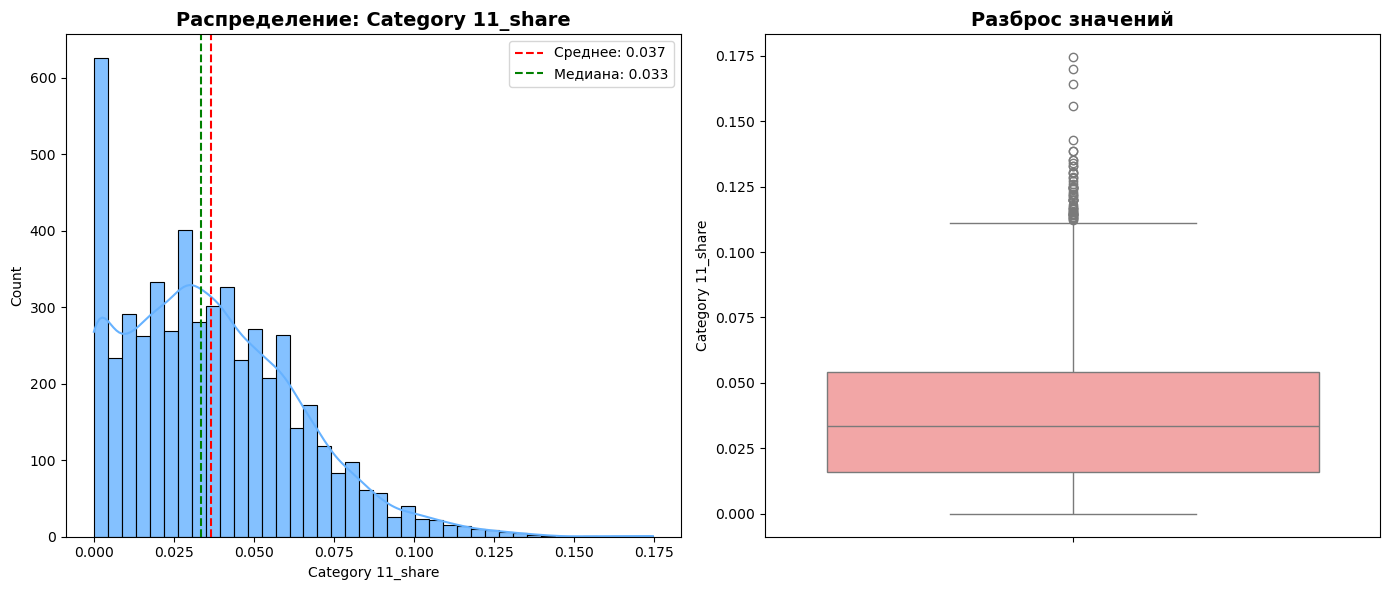


=== АНАЛИЗ ПРИЗНАКА: Category 12_share ===
Среднее: 0.0479
Медиана: 0.0466
Стандартное отклонение: 0.0305
Минимум: 0.0000
Максимум: 0.1786
Пропуски: 0
Выбросы (по IQR): 34


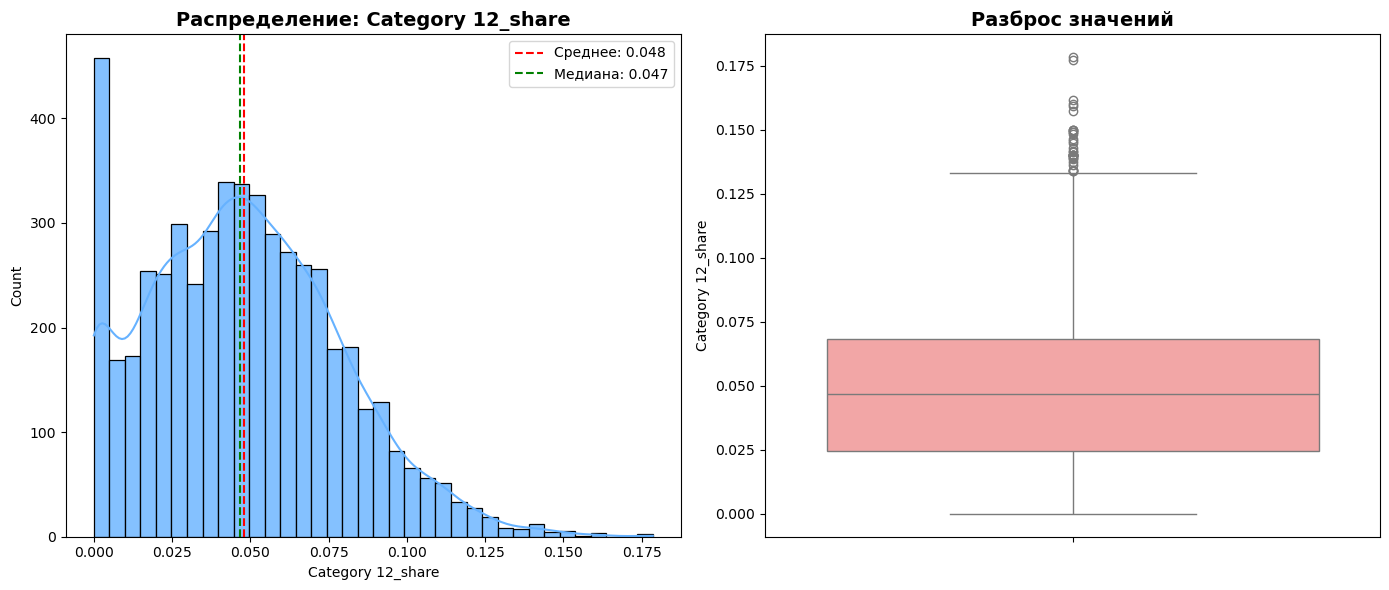


=== АНАЛИЗ ПРИЗНАКА: Category 13_share ===
Среднее: 0.0646
Медиана: 0.0574
Стандартное отклонение: 0.0570
Минимум: 0.0000
Максимум: 0.2959
Пропуски: 0
Выбросы (по IQR): 11


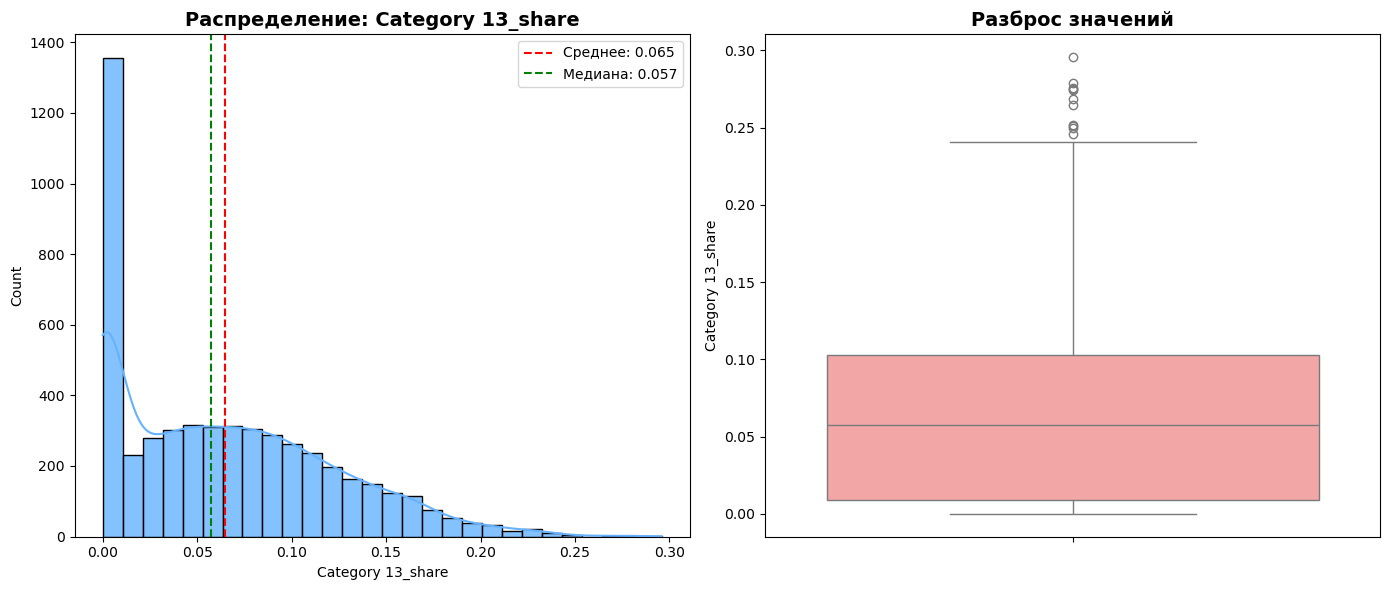


=== АНАЛИЗ ПРИЗНАКА: Category 14_share ===
Среднее: 0.0434
Медиана: 0.0412
Стандартное отклонение: 0.0297
Минимум: 0.0000
Максимум: 0.1900
Пропуски: 0
Выбросы (по IQR): 36


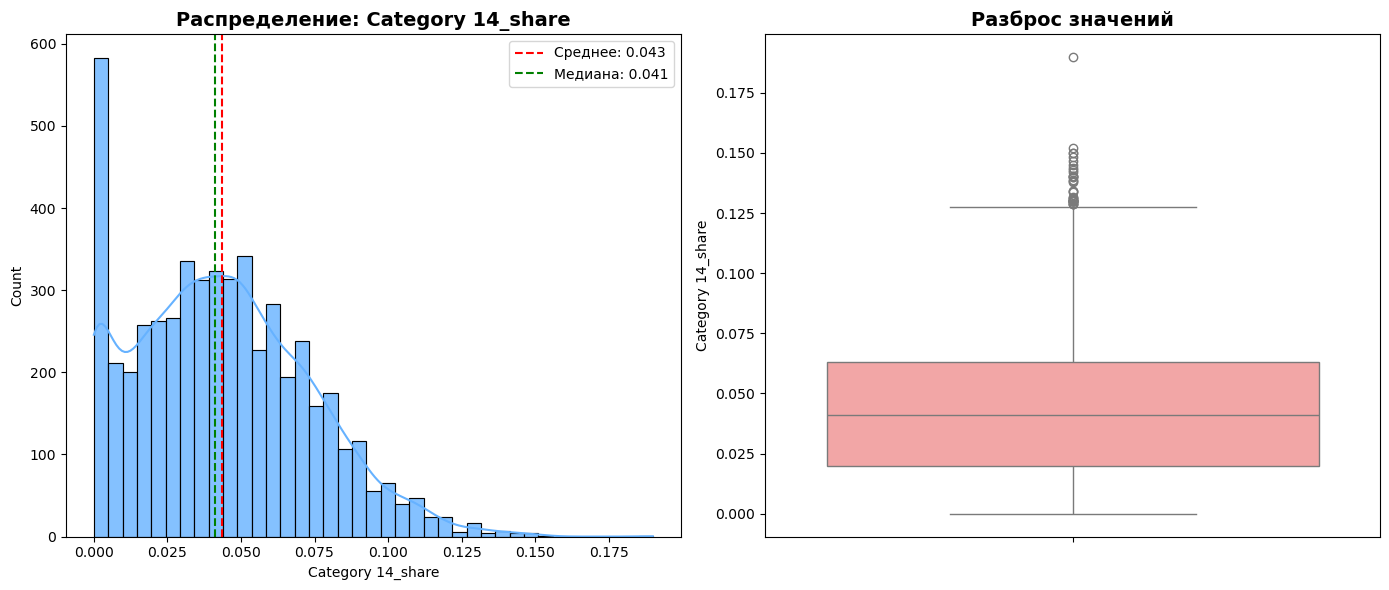


=== АНАЛИЗ ПРИЗНАКА: Category 15_share ===
Среднее: 0.0486
Медиана: 0.0474
Стандартное отклонение: 0.0284
Минимум: 0.0000
Максимум: 0.1980
Пропуски: 0
Выбросы (по IQR): 49


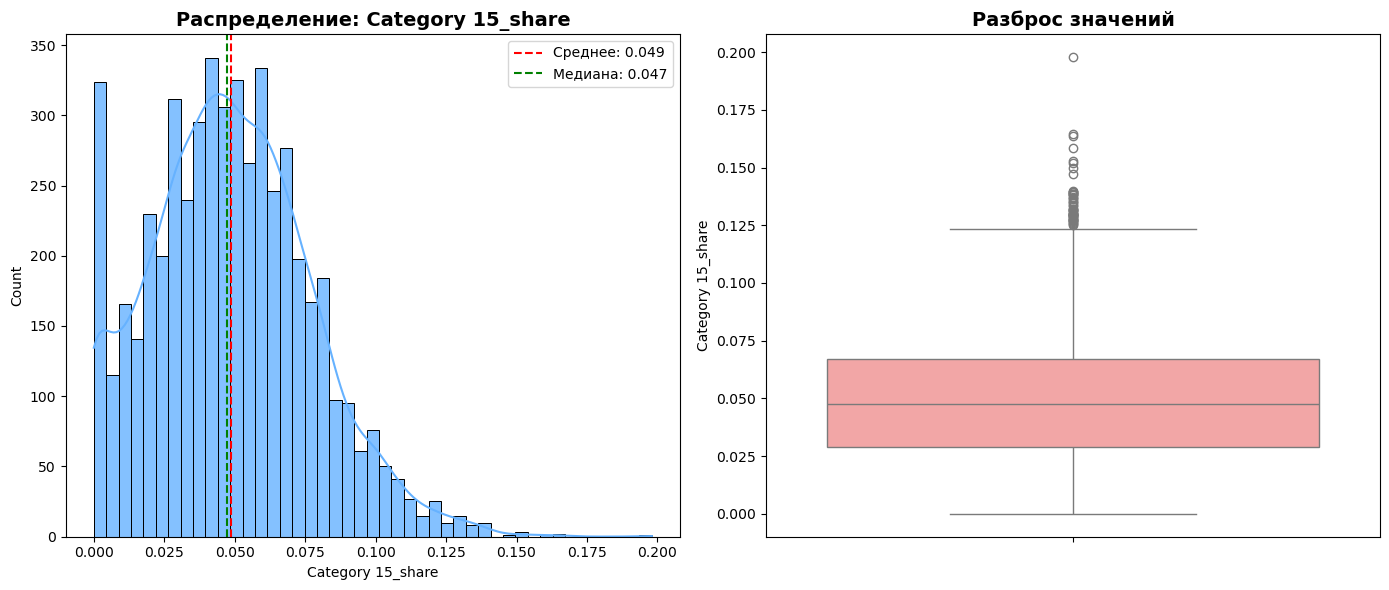


=== АНАЛИЗ ПРИЗНАКА: Category 16_share ===
Среднее: 0.0432
Медиана: 0.0403
Стандартное отклонение: 0.0285
Минимум: 0.0000
Максимум: 0.1594
Пропуски: 0
Выбросы (по IQR): 57


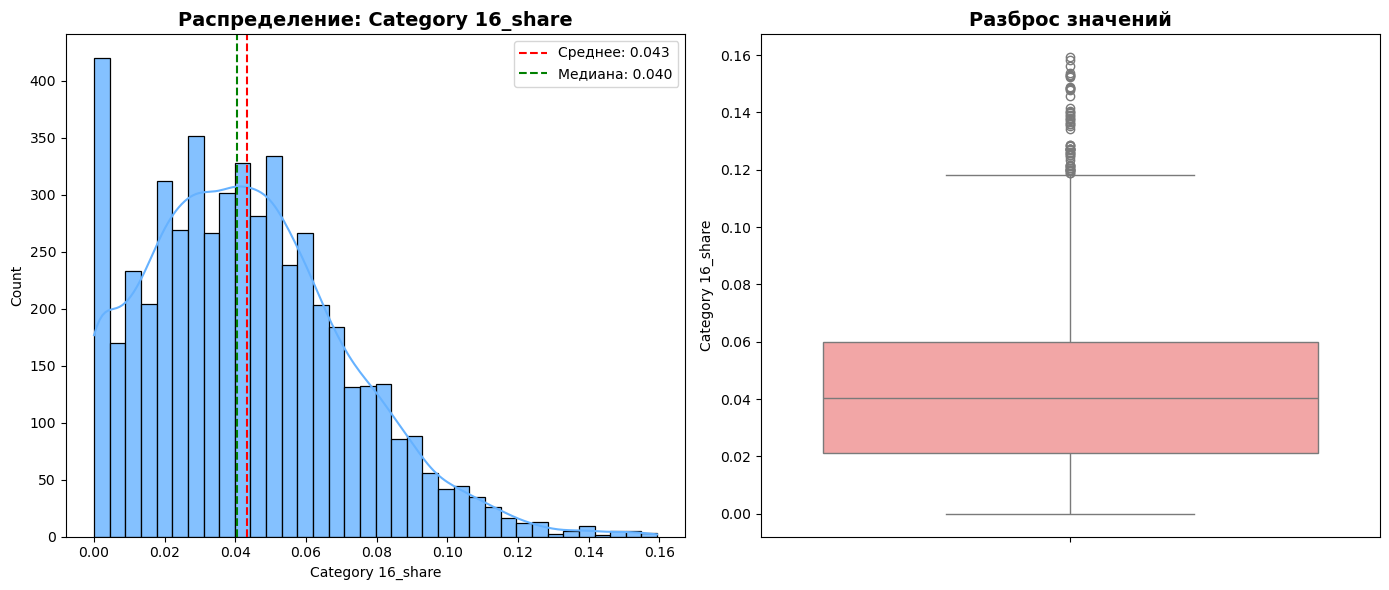


=== АНАЛИЗ ПРИЗНАКА: Category 17_share ===
Среднее: 0.0471
Медиана: 0.0452
Стандартное отклонение: 0.0292
Минимум: 0.0000
Максимум: 0.1880
Пропуски: 0
Выбросы (по IQR): 46


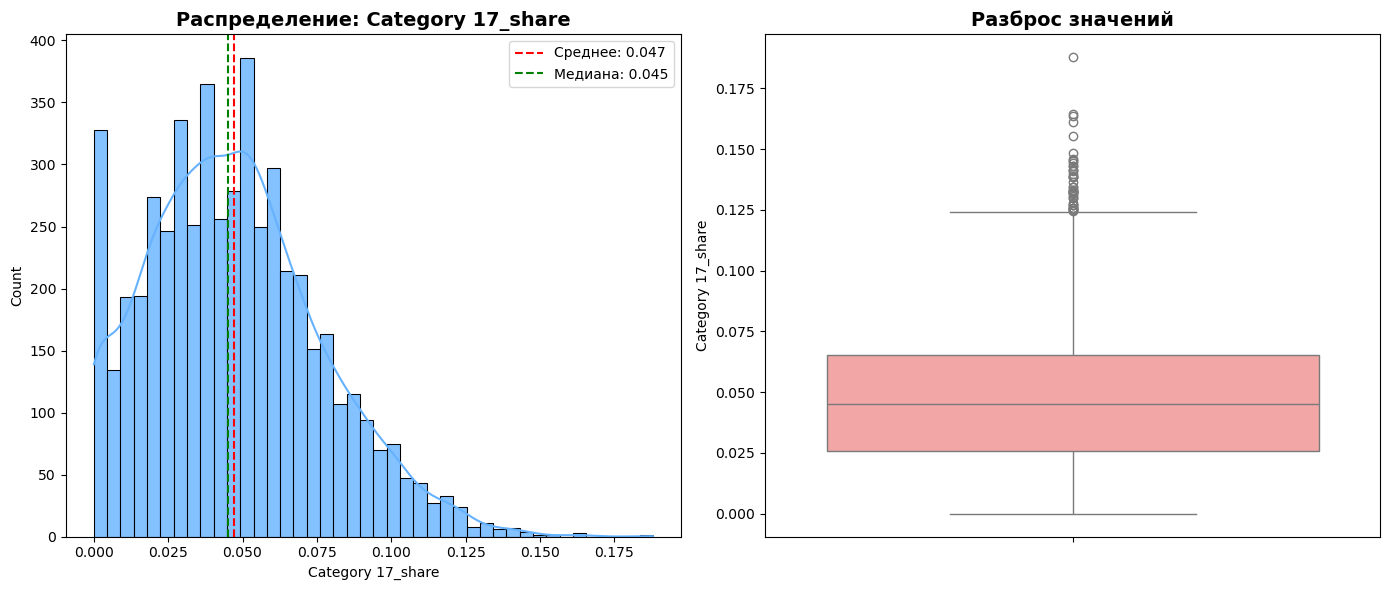


=== АНАЛИЗ ПРИЗНАКА: Category 18_share ===
Среднее: 0.0478
Медиана: 0.0440
Стандартное отклонение: 0.0318
Минимум: 0.0000
Максимум: 0.1958
Пропуски: 0
Выбросы (по IQR): 58


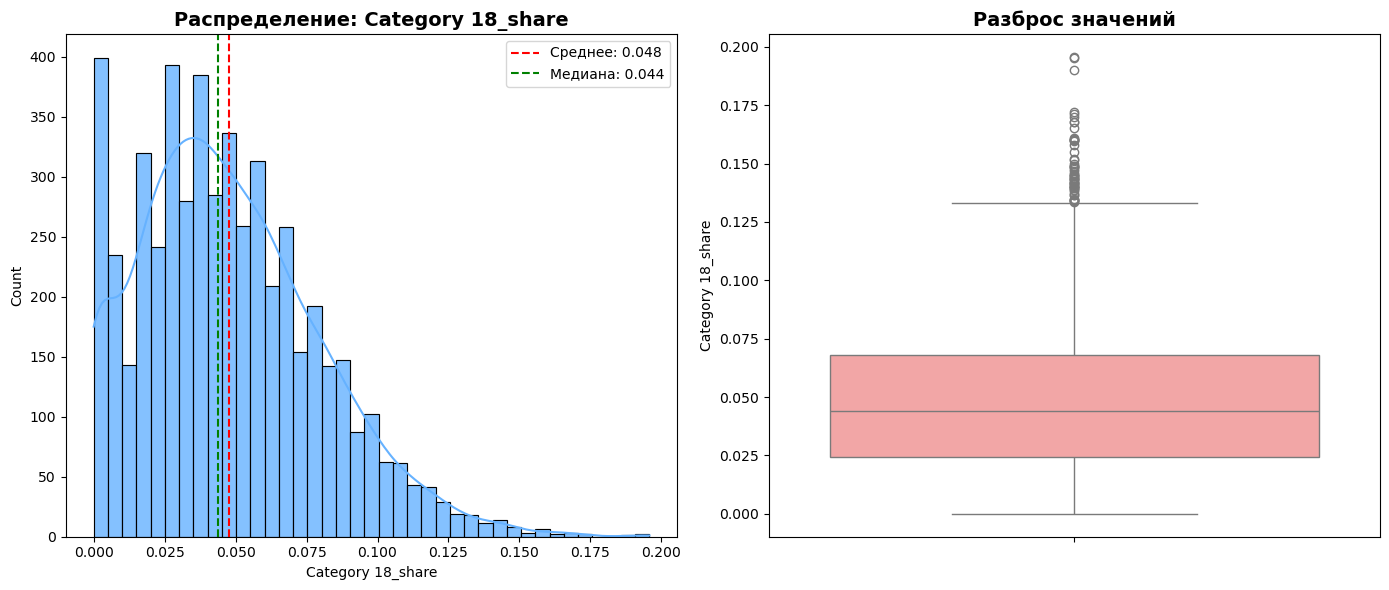


=== АНАЛИЗ ПРИЗНАКА: Category 19_share ===
Среднее: 0.0519
Медиана: 0.0500
Стандартное отклонение: 0.0288
Минимум: 0.0000
Максимум: 0.1800
Пропуски: 0
Выбросы (по IQR): 46


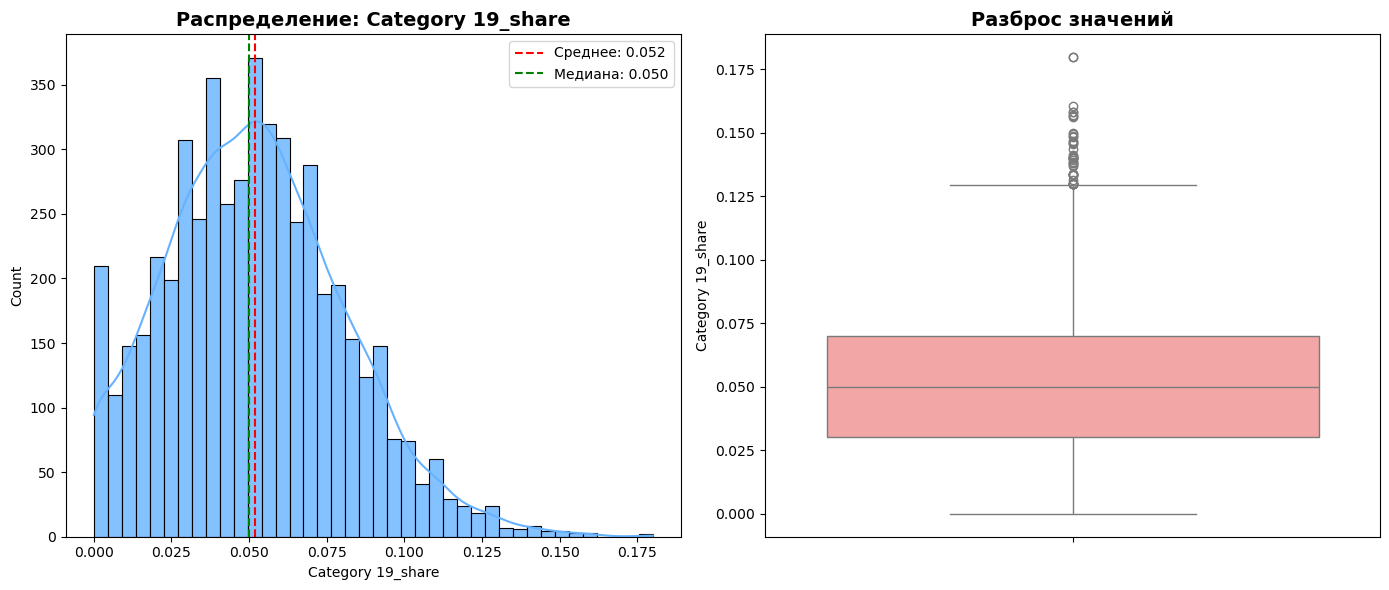


=== АНАЛИЗ ПРИЗНАКА: Category 20_share ===
Среднее: 0.0480
Медиана: 0.0457
Стандартное отклонение: 0.0290
Минимум: 0.0000
Максимум: 0.1682
Пропуски: 0
Выбросы (по IQR): 47


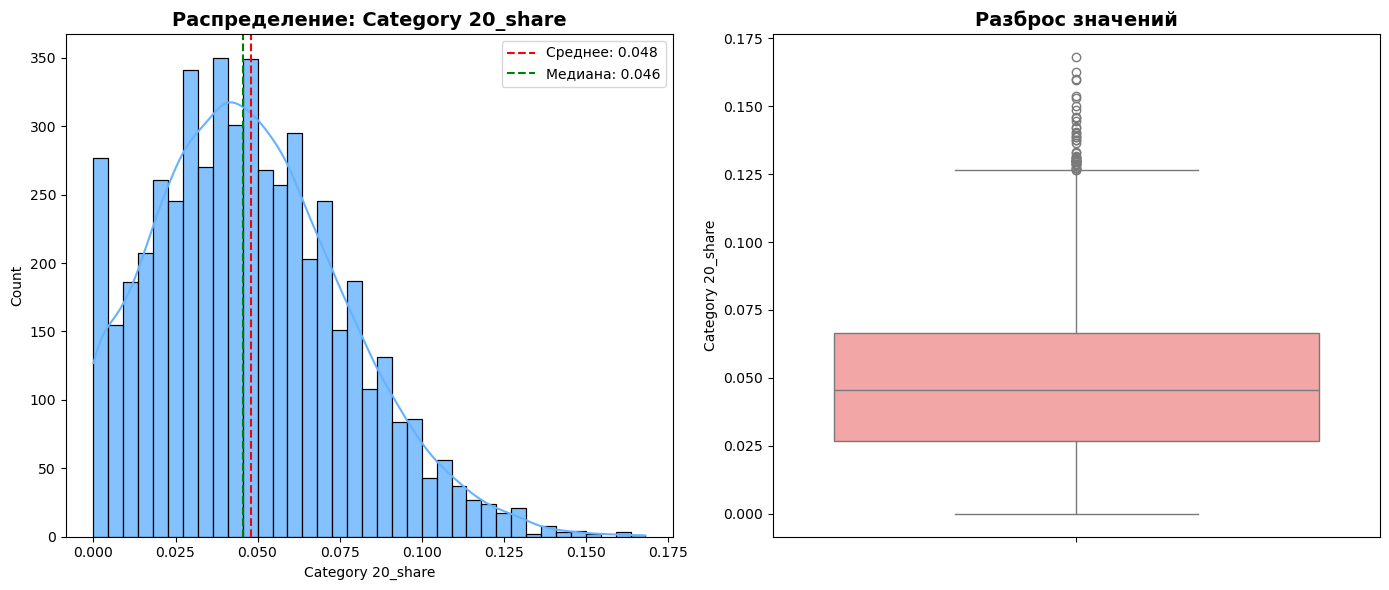


=== АНАЛИЗ ПРИЗНАКА: avg_daily_sessions ===
Среднее: 12.8889
Медиана: 11.9286
Стандартное отклонение: 5.4313
Минимум: 7.1429
Максимум: 59.9286
Пропуски: 0
Выбросы (по IQR): 173


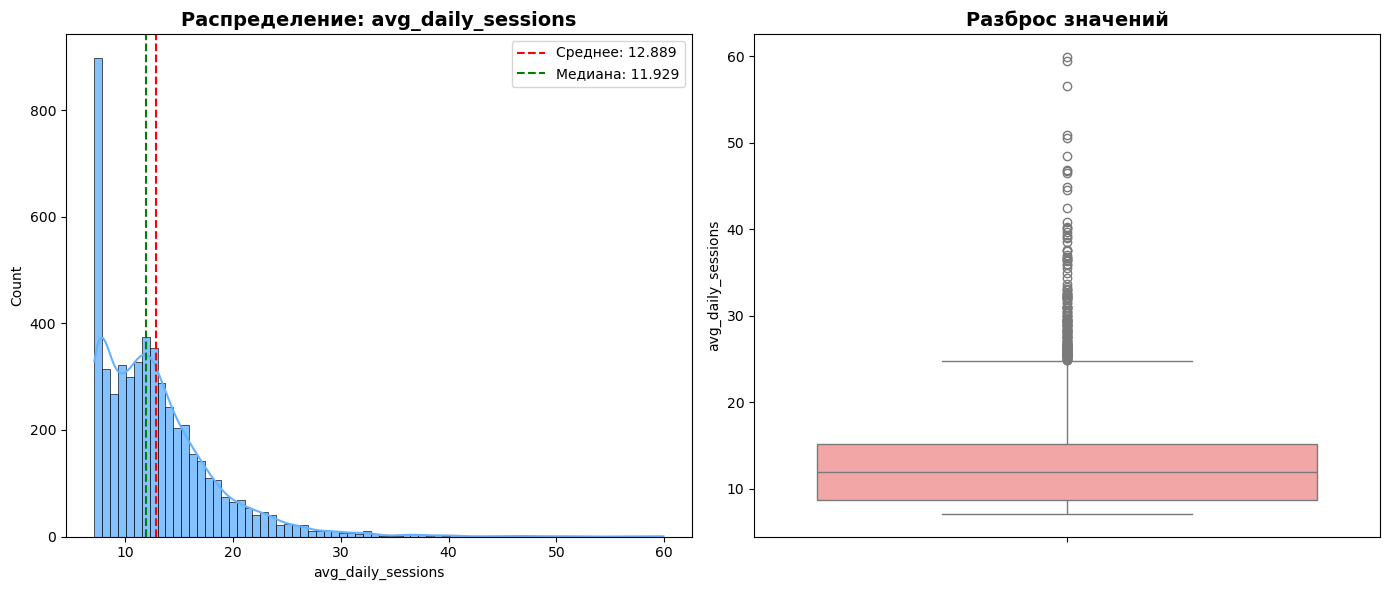


=== АНАЛИЗ ПРИЗНАКА: вечер_share ===
Среднее: 0.3587
Медиана: 0.3580
Стандартное отклонение: 0.0490
Минимум: 0.2143
Максимум: 0.5300
Пропуски: 0
Выбросы (по IQR): 24


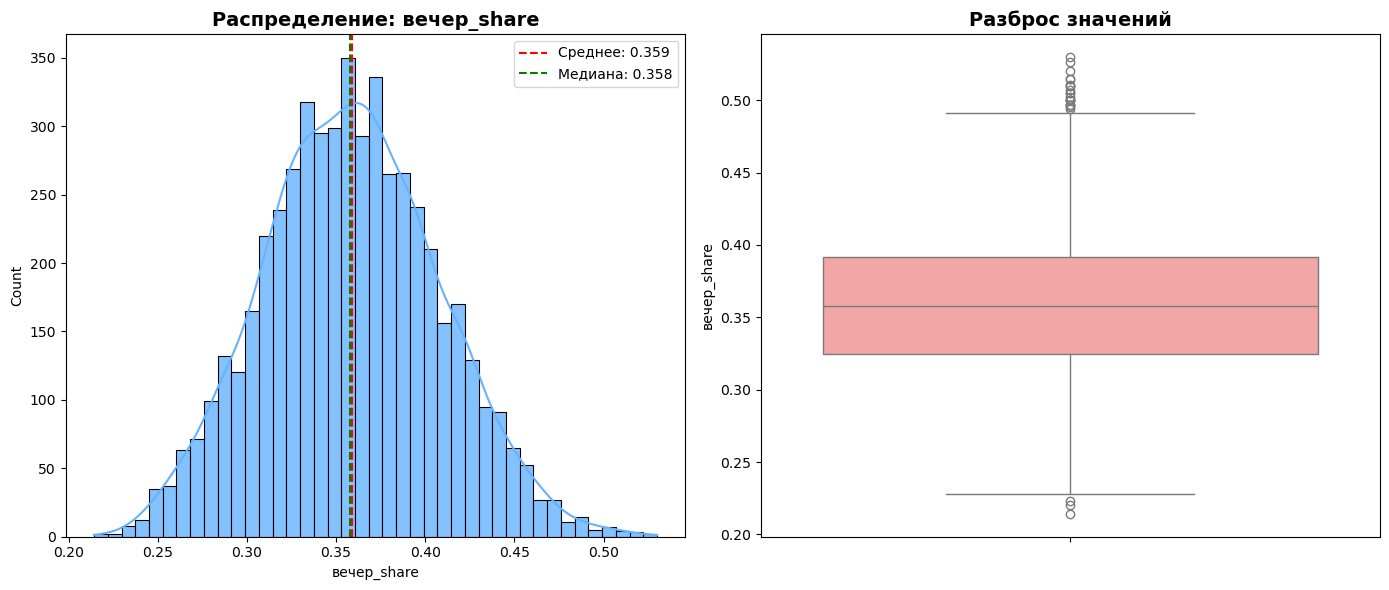


=== АНАЛИЗ ПРИЗНАКА: день_share ===
Среднее: 0.3645
Медиана: 0.3650
Стандартное отклонение: 0.0453
Минимум: 0.2178
Максимум: 0.5327
Пропуски: 0
Выбросы (по IQR): 45


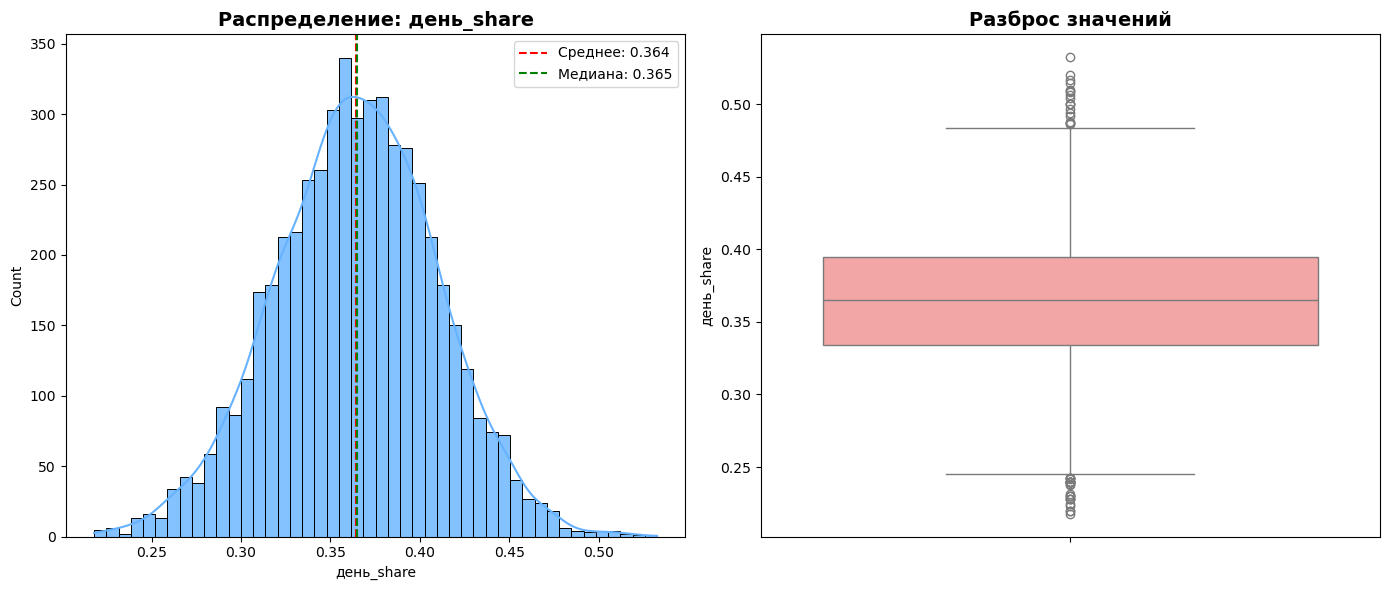


=== АНАЛИЗ ПРИЗНАКА: ночь_share ===
Среднее: 0.0782
Медиана: 0.0761
Стандартное отклонение: 0.0247
Минимум: 0.0000
Максимум: 0.1980
Пропуски: 0
Выбросы (по IQR): 59


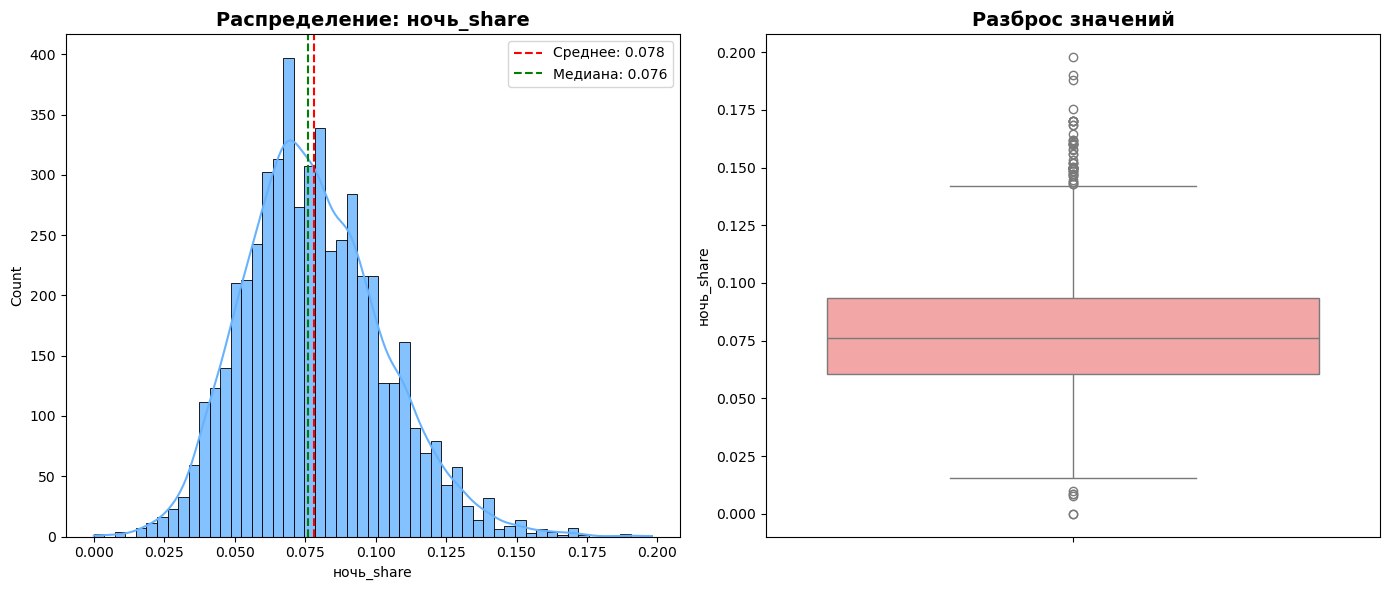


=== АНАЛИЗ ПРИЗНАКА: утро_share ===
Среднее: 0.1987
Медиана: 0.1969
Стандартное отклонение: 0.0379
Минимум: 0.0495
Максимум: 0.3396
Пропуски: 0
Выбросы (по IQR): 39


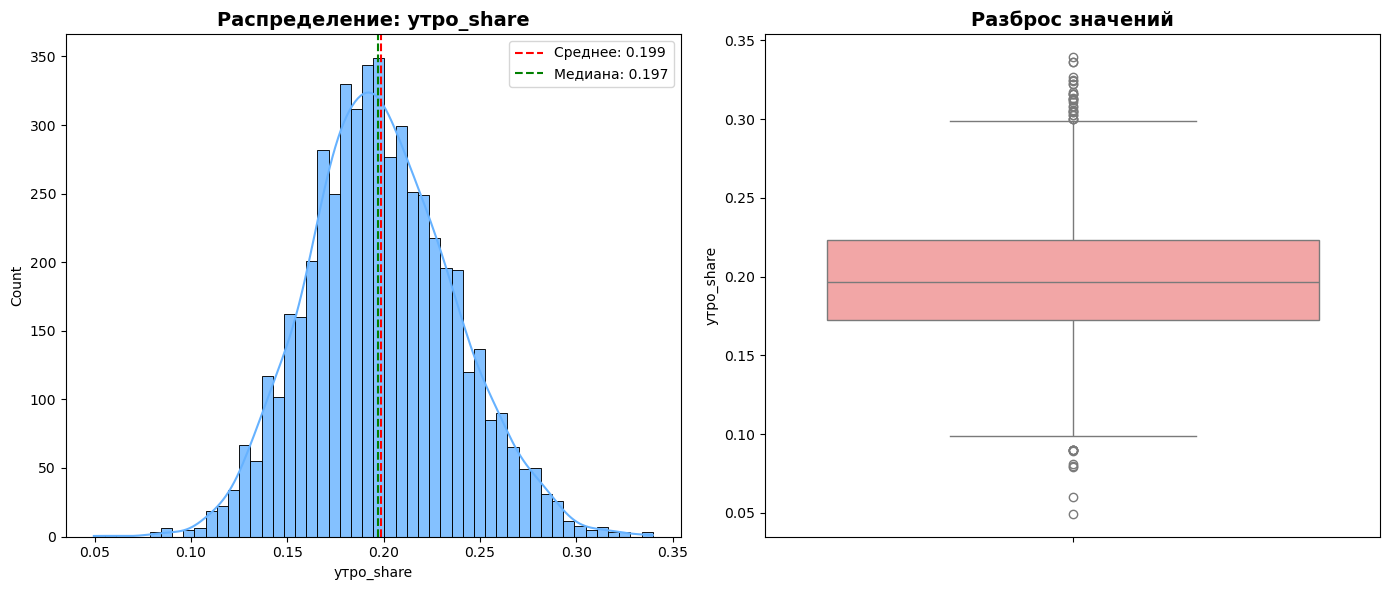

In [22]:
def analyze_and_plot_feature(feature_name, data):
    """Анализ и визуализация признака с выводом статистики"""
    print(f"\n=== АНАЛИЗ ПРИЗНАКА: {feature_name} ===")
    print(f"Среднее: {data[feature_name].mean():.4f}")
    print(f"Медиана: {data[feature_name].median():.4f}")
    print(f"Стандартное отклонение: {data[feature_name].std():.4f}")
    print(f"Минимум: {data[feature_name].min():.4f}")
    print(f"Максимум: {data[feature_name].max():.4f}")
    print(f"Пропуски: {data[feature_name].isnull().sum()}")
    
    # Определение выбросов по методу IQR
    Q1 = data[feature_name].quantile(0.25)
    Q3 = data[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)).sum()
    print(f"Выбросы (по IQR): {outliers_count}")
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Гистограмма
    sns.histplot(data=data, x=feature_name, kde=True, ax=ax1, color='#66B2FF', alpha=0.8)
    ax1.axvline(data[feature_name].mean(), color='red', linestyle='--', label=f'Среднее: {data[feature_name].mean():.3f}')
    ax1.axvline(data[feature_name].median(), color='green', linestyle='--', label=f'Медиана: {data[feature_name].median():.3f}')
    ax1.legend()
    ax1.set_title(f'Распределение: {feature_name}', fontsize=14, fontweight='bold')
    
    # Боксплот
    sns.boxplot(data=data, y=feature_name, ax=ax2, color='#FF9999')
    ax2.set_title('Разброс значений', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Анализ всех числовых признаков
for feature in num_feature:
    analyze_and_plot_feature(feature, df)

- Данные Category_share имеют в большинстве своём нормальное распределение с небольшим правосторонним хвостом.
- Данные по времени суток имеют нормальное распределение
- Даннные `avg_daily_sessions` имеют сильный правосторонний хвост

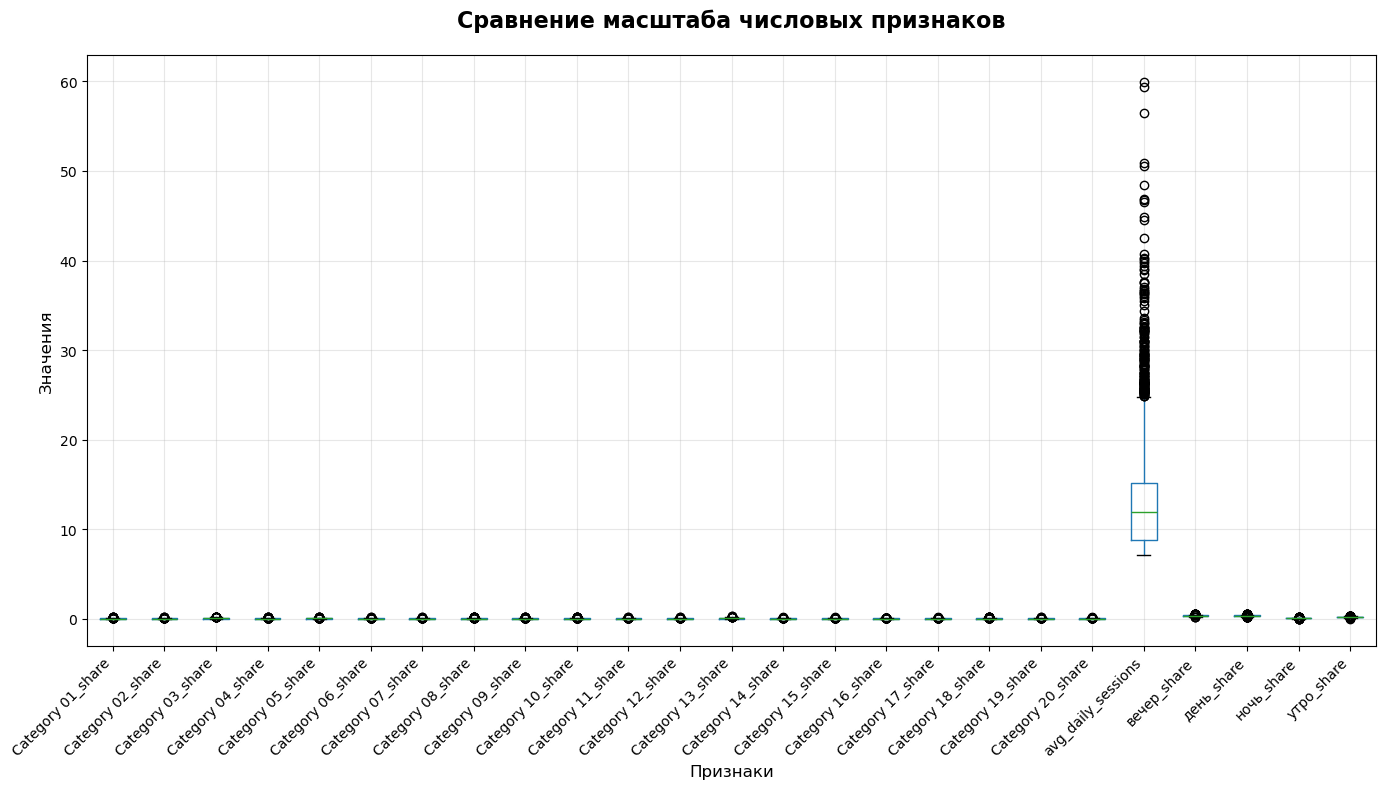

In [23]:
def plot_numerical_boxplots_basic(data, features, figsize=(14, 8),
                              title="Сравнение масштаба числовых признаков"):
    """
    Базовая функция для построения боксплотов числовых признаков.
    
    Параметры:
    - data: DataFrame с данными;
    - features: список признаков для визуализации;
    - figsize: размер фигуры;
    - title: заголовок графика.
    """
    # Проверяем, что все указанные признаки есть в данных
    missing_features = [f for f in features if f not in data.columns]
    if missing_features:
        raise ValueError(f"Следующие признаки отсутствуют в данных: {missing_features}")
    
    
    # Создаём фигуру и график
    fig, ax = plt.subplots(figsize=figsize)
    
    # Строим боксплоты для выбранных признаков
    data[features].boxplot(ax=ax, showfliers=True)
    
    # Настройка оформления
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Признаки', fontsize=12)
    ax.set_ylabel('Значения', fontsize=12)
    plt.xticks(rotation=45, ha='right')  # Поворот подписей для лучшей читаемости
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Использование
plot_numerical_boxplots_basic(df, num_feature)

Вполне очевидно, что все числовые признаки кроме среднего количества посещений будут одинакового масштаба, т.к. это доли



=== АНАЛИЗ ПРИЗНАКА: most_active_period ===
Всего наблюдений: 5205
Уникальных категорий: 3
Распределение по категориям:
  день: 2741 (52.7%)
  вечер: 2462 (47.3%)
  утро: 2 (0.0%)


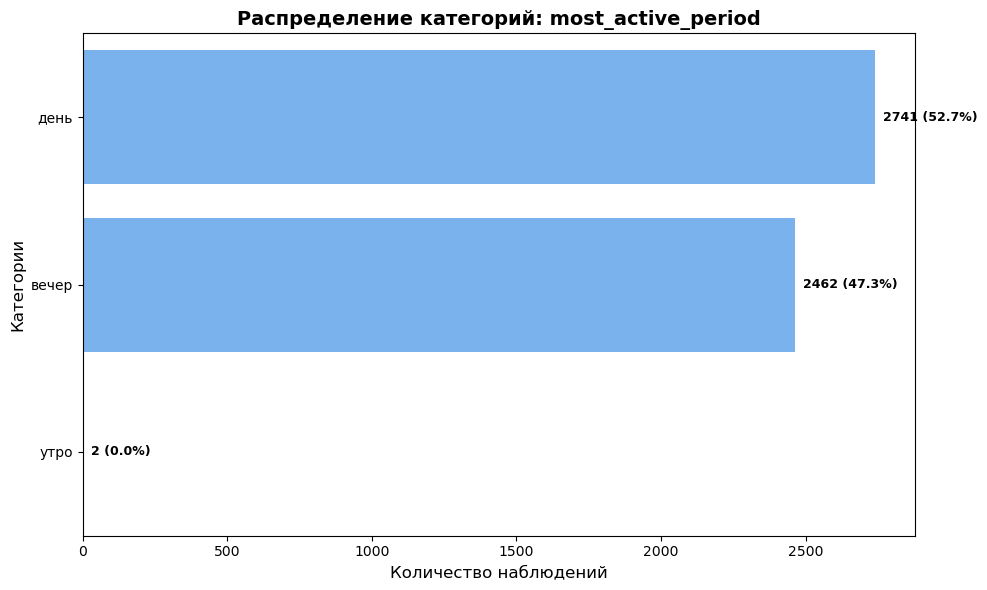


=== АНАЛИЗ ПРИЗНАКА: surf_depth ===
Всего наблюдений: 5205
Уникальных категорий: 3
Распределение по категориям:
  средне: 2223 (42.7%)
  поверхностно: 2210 (42.5%)
  глубоко: 772 (14.8%)


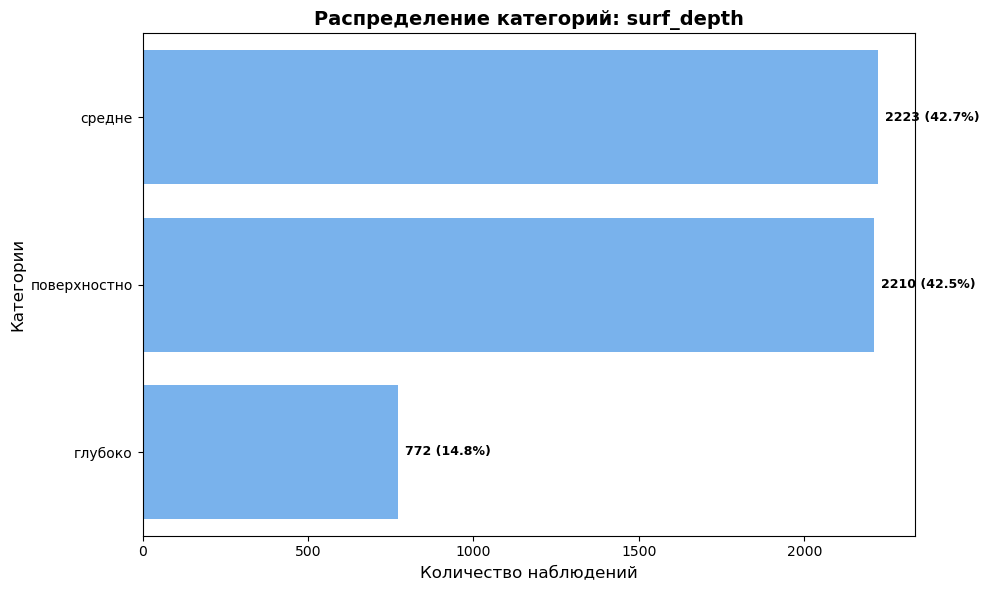


=== АНАЛИЗ ПРИЗНАКА: primary_device ===
Всего наблюдений: 5205
Уникальных категорий: 4
Распределение по категориям:
  смартфон: 2844 (54.6%)
  ПК: 1172 (22.5%)
  ноутбук: 837 (16.1%)
  планшет: 352 (6.8%)


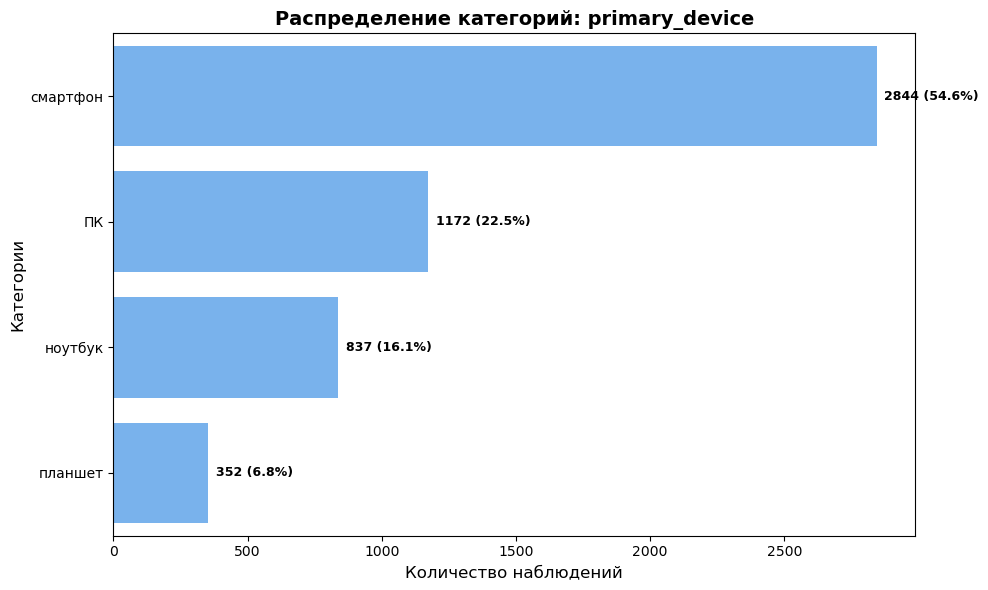


=== АНАЛИЗ ПРИЗНАКА: cloud_usage ===
Всего наблюдений: 5205
Уникальных категорий: 2
Распределение по категориям:
  True: 2724 (52.3%)
  False: 2481 (47.7%)


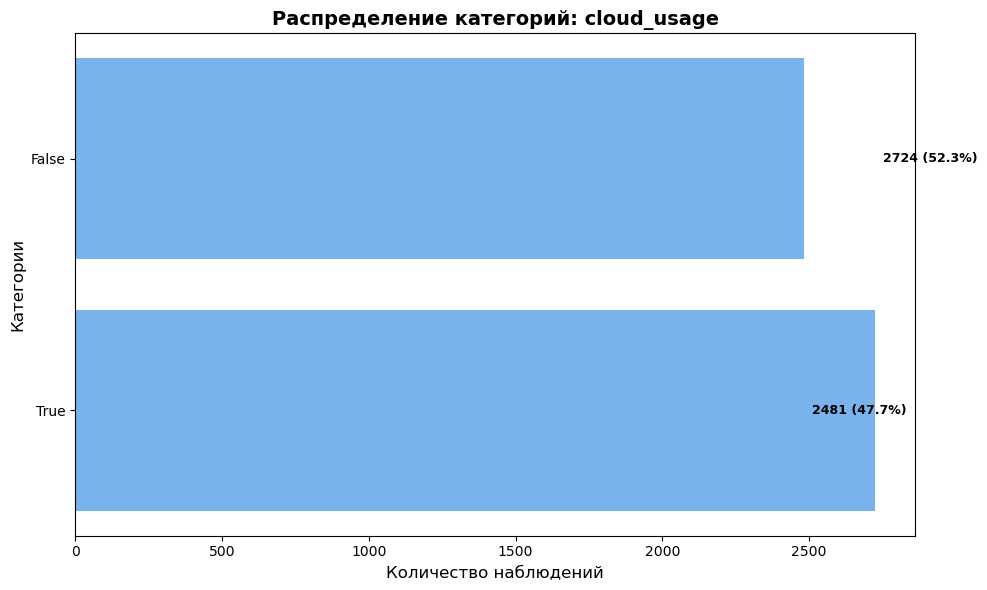


=== АНАЛИЗ ПРИЗНАКА: ads_activity ===
Всего наблюдений: 5205
Уникальных категорий: 5
Распределение по категориям:
  умеренно: 1696 (32.6%)
  редко: 1522 (29.2%)
  часто: 996 (19.1%)
  очень редко: 783 (15.0%)
  очень часто: 208 (4.0%)


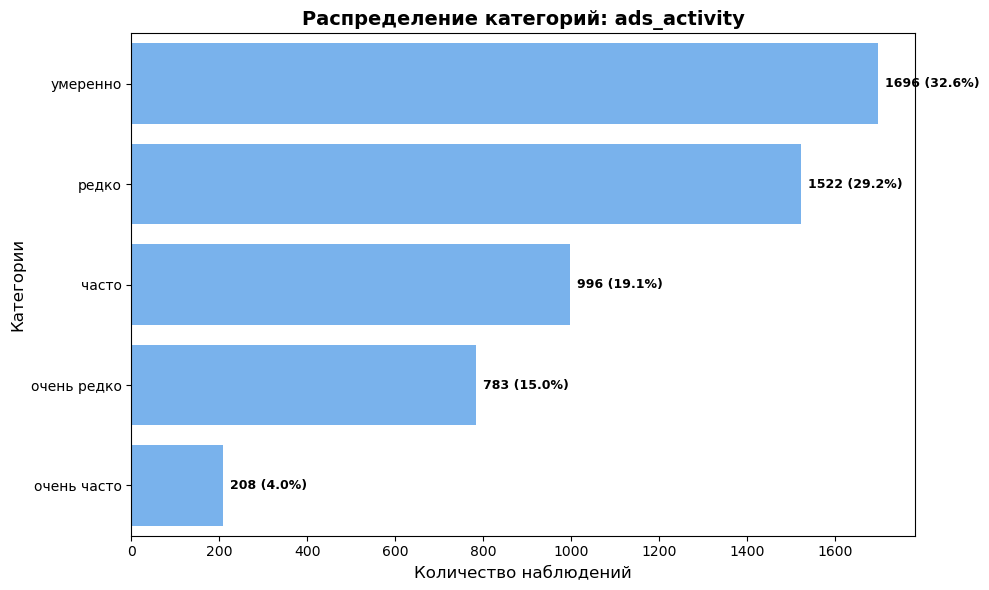

In [24]:
def plot_categorical_distribution(feature_name, data):
    """Функция для построения столбчатой диаграммы с дополнительной статистикой"""
    print(f"\n=== АНАЛИЗ ПРИЗНАКА: {feature_name} ===")
    print(f"Всего наблюдений: {len(data[feature_name])}")
    print(f"Уникальных категорий: {data[feature_name].nunique()}")
    
    # Распределение категорий
    value_counts = data[feature_name].value_counts()
    value_percentages = data[feature_name].value_counts(normalize=True) * 100
    
    print("Распределение по категориям:")
    for category, count, percentage in zip(value_counts.index, value_counts.values, value_percentages.values):
        print(f"  {category}: {count} ({percentage:.1f}%)")
    
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=value_counts.values, y=value_counts.index, ax=ax, color = '#66B2FF')   
    
    # Подписи значений
    for i, v in enumerate(value_counts.values):
        ax.text(v + value_counts.values.max() * 0.01, i, f'{v} ({value_percentages.iloc[i]:.1f}%)',
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f'Распределение категорий: {feature_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Количество наблюдений', fontsize=12)
    ax.set_ylabel('Категории', fontsize=12)
    plt.tight_layout()
    plt.show()

# Построение графиков для каждого категориального признака
for feature in cat_feature:
    plot_categorical_distribution(feature, df)

1. `most_active_period` (время наибольшей активности)

- подавляющее большинство пользователей активны днём (52,7 %, 2 741 человек) или вечером (47,3 %, 2 462 человека);

- активность утром крайне низкая — всего 2 наблюдения (0,0 %).

2. `surf_depth`

- примерно поровну пользователей с «средней» (42,7 %, 2 223) и «поверхностной» (42,5 %, 2 210) глубиной сёрфинга;

- глубокая навигация встречается значительно реже (14,8 %, 772).

3. `primary_device` (основное устройство)

- смартфон — основное устройство для большинства пользователей (54,6 %, 2 844);

- ПК и ноутбуки используются реже (22,5 % и 16,1 % соответственно);

- планшеты наименее популярны (6,8 %, 352).

4. `cloud_usage` (использование облачных сервисов)

- практически равное распределение: 52,3 % используют облачные сервисы (2 724), 47,7 % — нет (2 481).

5. `ads_activity` (активность взаимодействия с рекламой)

- большинство пользователей взаимодействуют с рекламой умеренно (32,6 %, 1 696) или редко (29,2 %, 1 522);

- частое взаимодействие — у 19,1 % (996);

- очень редкое и очень частое взаимодействие встречаются реже (15,0 % и 4,0 % соответственно).

6. Максимальное число категорий 5 (ads_activity), в качестве кодировщика будем использовать метод OneHotEncoder

In [25]:
df = df.drop(columns = 'user_id')

### Анализ корреляций

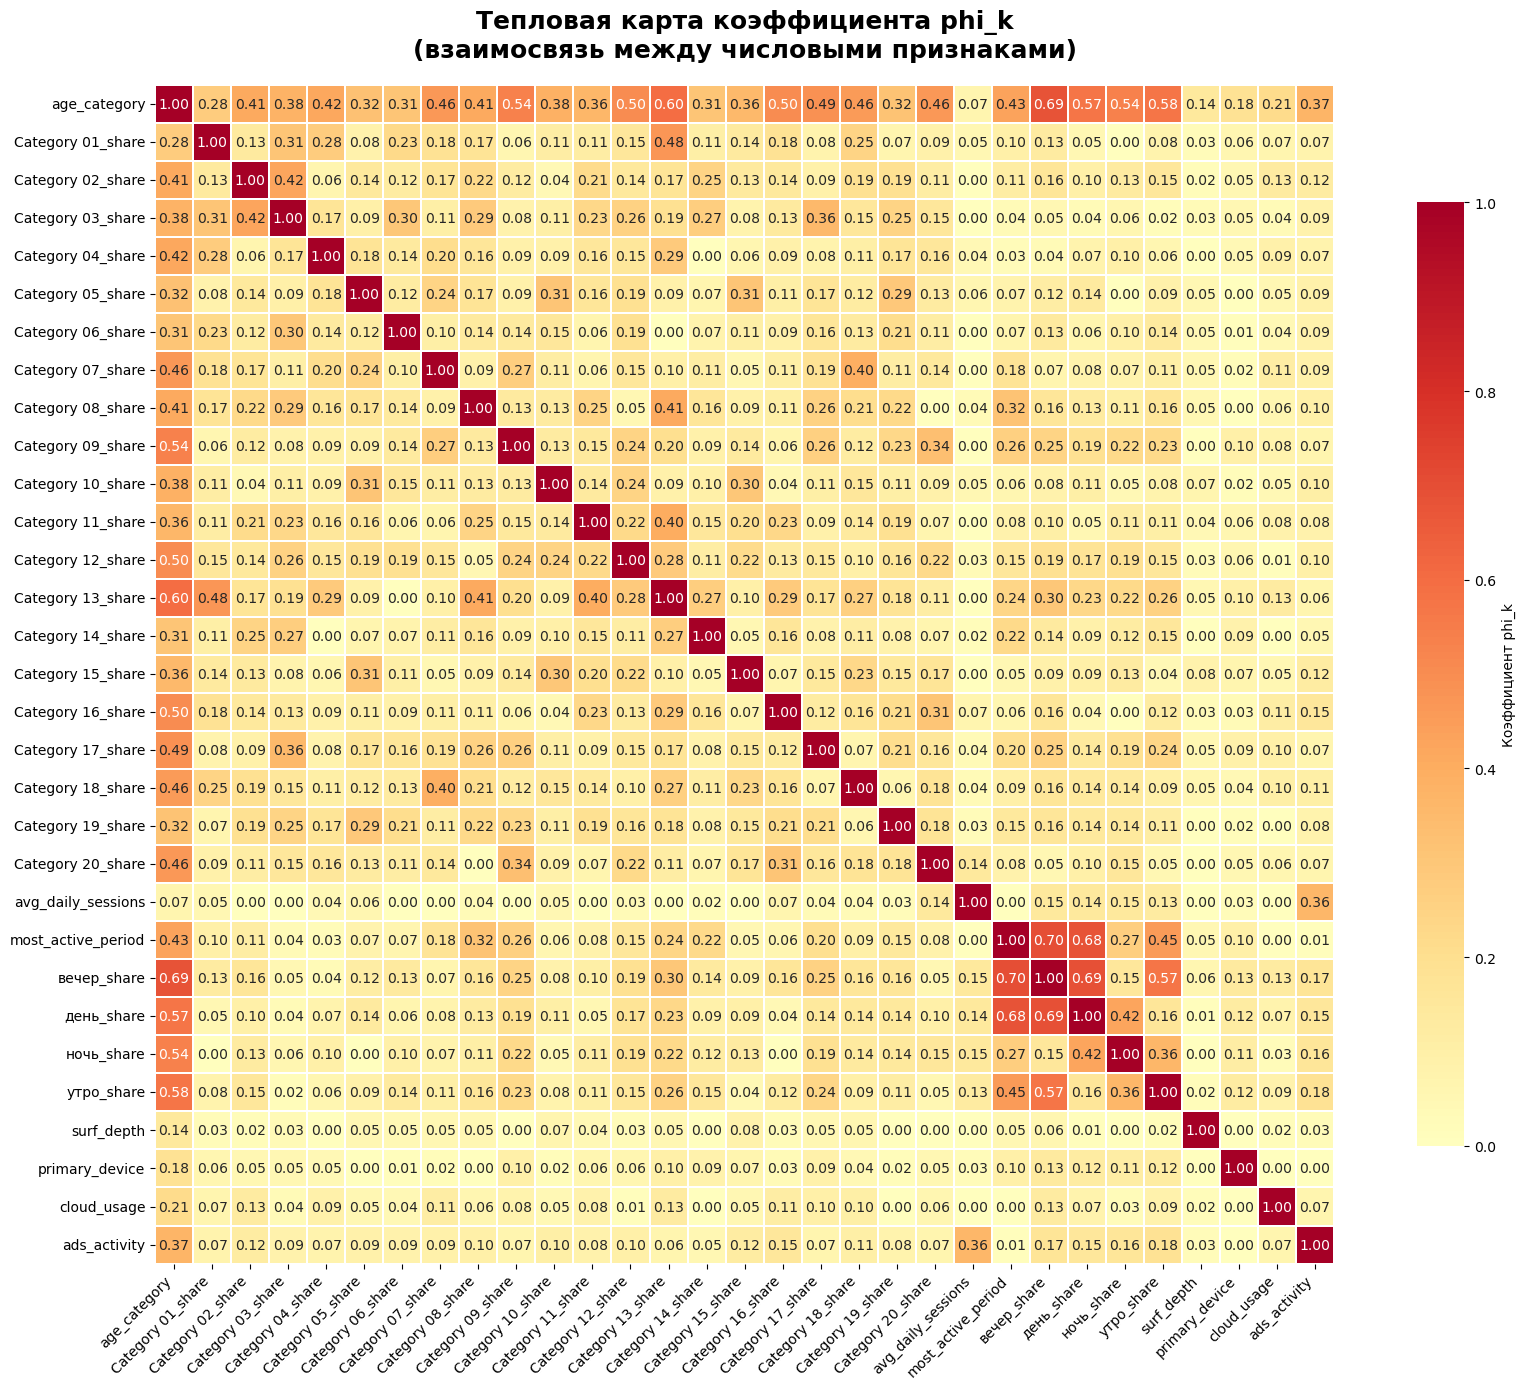

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.7):
most_active_period ↔ вечер_share: 0.702


In [26]:
# Вычисляем матрицу корреляций
correlation_matrix = df.phik_matrix(
    interval_cols=['Category 01_share', 'Category 02_share',
       'Category 03_share', 'Category 04_share', 'Category 05_share',
       'Category 06_share', 'Category 07_share', 'Category 08_share',
       'Category 09_share', 'Category 10_share', 'Category 11_share',
       'Category 12_share', 'Category 13_share', 'Category 14_share',
       'Category 15_share', 'Category 16_share', 'Category 17_share',
       'Category 18_share', 'Category 19_share', 'Category 20_share',
       'avg_daily_sessions', 'вечер_share', 'день_share',
       'ночь_share', 'утро_share'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()


print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= 0.7:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")

Анализ матрицы корреляций показывает довольно благоприятную картину. Из всех признаков сильную кореляцию показывают только пара most_active_period ↔ вечер_share: 0.702. Также большинство признаков в разном диапазоне влияют на целевую переменную. 

### Вывод по проделанной работе

В ходе исследовательского анализа данных (EDA) выполнен комплекс задач — от первичной проверки до углублённого изучения взаимосвязей признаков. 

1. Первичный анализ данных
- Изучены 6 таблиц датасета.

- Проведена проверка на пропущенные значения — выявлена их доля и распределение по таблицам.

- Выполнена проверка на дубликаты — при обнаружении проведены очистка и дедупликация.

2. Подготовка данных и формирование признаков

- Таблица visits (данные о сессиях пользователей) детально изучена и использована для создания новых признаков (агрегации, временные метрики и т. д.).

- Разработана функция для объединения таблиц в единый датафрейм — сформировано признаковое пространство для дальнейшего моделирования.

- Признаки разделены на числовые и категориальные для дифференцированной обработки.

3. Визуальный анализ распределения признаков  
Для числовых признаков:

- построены гистограммы — оценена форма распределения (нормальность, скошенность, выбросы);

- проанализированы боксплоты — выявлены выбросы и межквартильный размах.

Для категориальных признаков:

- построены столбчатые диаграммы — изучены частоты категорий, выявлены редкие и доминирующие классы.

4. Анализ целевой переменной  
- Выявлен сильный дисбаланс классов в целевой переменной.

Это требует учёта при моделировании:

- выбора метрик качества (precision, recall, F1, ROC‑AUC вместо accuracy);

- настройки пороговых вероятностей классификации.

5. Анализ взаимосвязей и корреляций

- Построена матрица корреляций для числовых признаков.

- Изучено влияние признаков на целевую переменную (точечные диаграммы, групповые статистики, ANOVA для категориальных факторов).

- Выявлены сильные и умеренные корреляции между отдельными признаками — это может указывать на потенциальную мультиколлинеарность (требует дополнительной проверки, например, через VIF).

## Предобработка данных

### Разделение на выборки

In [27]:
# Сначала отделяем признаки и целевую переменную
X = df.drop('age_category', axis=1)
y = df['age_category']

# Затем разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   
    random_state=42,  
    stratify=y,
    shuffle = True
)

print("Размеры:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры:
X_train: (4164, 30)
X_test: (1041, 30)
y_train: (4164,)
y_test: (1041,)


In [28]:
# Функция для подсчёта распределения категорий
def print_class_distribution(y_data, dataset_name):
    print(f"\nРАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В {dataset_name}")
    total = len(y_data)
    for category in range(5):  # категории 0, 1, 2, 3, 4
        count = (y_data == category).sum()
        ratio = count / total
        print(f"Категория {category}: {count} записей ({ratio*100:.2f} %)")

# Распределение в обучающей выборке
print_class_distribution(y_train, "ОБУЧАЮЩЕЙ ВЫБОРКЕ")

# Распределение в тестовой выборке
print_class_distribution(y_test, "ТЕСТОВОЙ ВЫБОРКЕ")


РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ОБУЧАЮЩЕЙ ВЫБОРКЕ
Категория 0: 616 записей (14.79 %)
Категория 1: 375 записей (9.01 %)
Категория 2: 1017 записей (24.42 %)
Категория 3: 900 записей (21.61 %)
Категория 4: 1256 записей (30.16 %)

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ТЕСТОВОЙ ВЫБОРКЕ
Категория 0: 154 записей (14.79 %)
Категория 1: 94 записей (9.03 %)
Категория 2: 254 записей (24.40 %)
Категория 3: 225 записей (21.61 %)
Категория 4: 314 записей (30.16 %)


**Анализ результатов разделения данных**  
Результаты показывают, что стратифицированное разделение (stratify=y) сработало корректно: распределение категорий в обучающей и тестовой выборках практически идентично.

### Создание пайплайнов и препроцессора

In [29]:
#Создаём пайпланы:
#Для числовых признаков
num_pipeline = Pipeline(steps = [
    ('обработка пропусков', SimpleImputer(strategy = 'median')),
    ('масштабирование', StandardScaler())
])

#Для категориальных
cat_pipeline = Pipeline(steps=[
    ('обработка пропусков', SimpleImputer(strategy = 'constant', fill_value= 'missing')),
    ('кодирование признаков', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Объединяем все пайплайны в один ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_feature),
    ('cat_OHE', cat_pipeline, cat_feature)],
remainder='drop'
)

## Обучение и оценка базовой модели

In [30]:
# Зафиксировали кросс-валидацию StratifiedKFold с зафиксированным random_state.
cv = StratifiedKFold(n_splits=5, random_state=RANDOM_SEED, shuffle=True)

In [31]:
dummy = DummyClassifier(strategy='prior', random_state=RANDOM_SEED)
# Кросс-валидация на 5 фолдах на отобранных данных
cv_scores_dummy = cross_val_score(dummy, X_train, y_train, cv=cv, 
                                   scoring='f1_macro')
print(f'DummyClassifier F1-macro: {cv_scores_dummy.mean():.4f} ± ({cv_scores_dummy.std():.4f})')

DummyClassifier F1-macro: 0.0927 ± (0.0001)


Значение 0,0927 говорит о том, что в среднем по классам модель показывает очень низкую эффективность.

Это ожидаемо для DummyClassifier, так как он:
- не использует признаки X;

- делает случайные предсказания с вероятностями, равными частотам классов в обучающей выборке.

## Создание и отбор признаков

In [32]:
preprocessor.fit(X_train, y_train)
X_train_transformed = pd.DataFrame(preprocessor.transform(X_train), columns=preprocessor.get_feature_names_out())
transformed_col_names = []

for column in preprocessor.get_feature_names_out():
    transformed_col_names.append(column[column.index('__') + 2:])

In [33]:
mi_scores = mutual_info_classif(X_train_transformed, y_train)
mi_scores = pd.Series(mi_scores, index=transformed_col_names)
mi_scores= mi_scores.sort_values(ascending=False).head(20)
print('Топ 20 признаков')
print(mi_scores)

Топ 20 признаков
вечер_share                 0.296448
утро_share                  0.194962
Category 13_share           0.190583
день_share                  0.173860
ночь_share                  0.172663
Category 09_share           0.170991
Category 16_share           0.157751
most_active_period_вечер    0.156582
most_active_period_день     0.154388
Category 12_share           0.149329
Category 17_share           0.148703
Category 07_share           0.146576
Category 20_share           0.145362
Category 08_share           0.128459
Category 04_share           0.127867
Category 18_share           0.127179
Category 02_share           0.111846
Category 14_share           0.109038
Category 03_share           0.106216
Category 10_share           0.104630
dtype: float64


Запуск Recursive Feature Elimination (RFE) из sklearn...
Подбор оптимального количества признаков с помощью кросс-валидации...


Перебор числа признаков:  12%|███████▍                                                   | 1/8 [00:02<00:16,  2.30s/it]

n_features=5: F1-macro=0.5488


Перебор числа признаков:  25%|██████████████▊                                            | 2/8 [00:04<00:14,  2.38s/it]

n_features=7: F1-macro=0.6391


...

Перебор числа признаков:  88%|███████████████████████████████████████████████████▋       | 7/8 [00:16<00:02,  2.21s/it]

n_features=17: F1-macro=0.7804


Перебор числа признаков: 100%|███████████████████████████████████████████████████████████| 8/8 [00:18<00:00,  2.28s/it]

n_features=19: F1-macro=0.7874

Оптимальное количество признаков: 19 (F1-macro: 0.7874)

Запуск финального RFE с 19 признаками...
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.


Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.

Выбранные признаки RFE (19): ['num__Category 02_share', 'num__Category 03_share', 'num__Category 04_share', 'num__Category 08_share', 'num__Category 09_share', 'num__Category 10_share', 'num__Category 12_share', 'num__Category 13_share', 'num__Category 14_share', 'num__Category 15_share', 'num__Category 16_share', 'num__Category 17_share', 'num__Category 18_share', 'num__Category 19_share', 'num__Category 20_share', 'num__вечер_share', 'num__день_share', 'num__ночь_share', 'num__утро_share']

Ранжирование признаков RFE:
                              feature  rank  selected
13             num__Cat

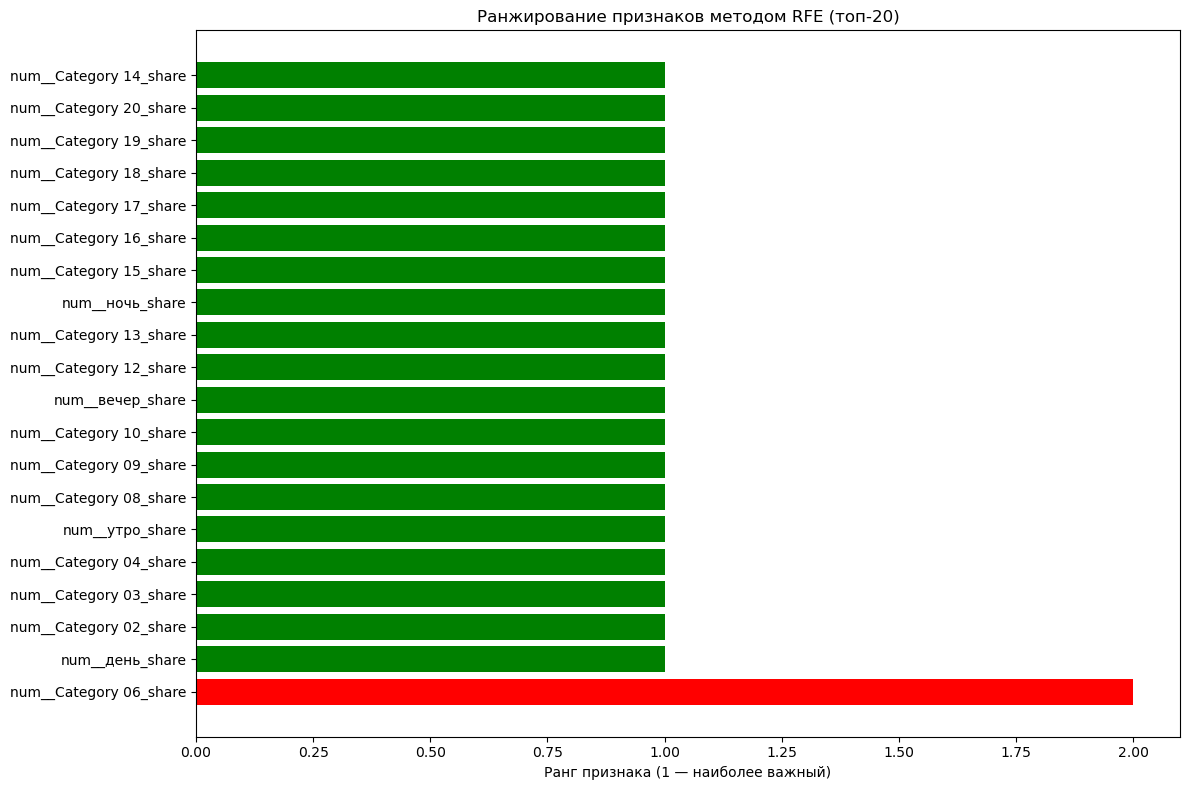


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Всего признаков: 42
Отобрано признаков: 19
Удалено признаков: 23

Распределение рангов:
Ранг 1: 19 признаков
Ранг 2: 1 признаков
Ранг 3: 1 признаков
Ранг 4: 1 признаков
Ранг 5: 1 признаков
Ранг 6: 1 признаков
Ранг 7: 1 признаков
Ранг 8: 1 признаков
Ранг 9: 1 признаков
Ранг 10: 1 признаков
Ранг 11: 1 признаков
Ранг 12: 1 признаков
Ранг 13: 1 признаков
Ранг 14: 1 признаков
Ранг 15: 1 признаков
Ранг 16: 1 признаков
Ранг 17: 1 признаков
Ранг 18: 1 признаков
Ранг 19: 1 признаков
Ранг 20: 1 признаков
Ранг 21: 1 признаков
Ранг 22: 1 признаков
Ранг 23: 1 признаков
Ранг 24: 1 признаков
--------------------------------------------------


In [34]:
print("Запуск Recursive Feature Elimination (RFE) из sklearn...")

# Параметры для подбора оптимального числа признаков
feature_counts = range(5, 21, 2)  # тестируем от 5 до 20 признаков с шагом 2
cv_scores = []

print("Подбор оптимального количества признаков с помощью кросс-валидации...")

for n_features in tqdm(feature_counts, desc="Перебор числа признаков"):
    try:
        # Создаём пайплайн: стандартизация + RFE + модель
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('rfe', RFE(
                estimator=LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
                n_features_to_select=n_features,
                step=1,
                verbose=0
            )),
            ('classifier', LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000))
        ])

        # Кросс-валидация всего пайплайна
        cv_score = cross_val_score(
            pipeline,
            X_train_transformed, y_train,
            cv=5,
            scoring='f1_macro'  # для мультикласса
        ).mean()
        cv_scores.append(cv_score)
        print(f"n_features={n_features}: F1-macro={cv_score:.4f}")
    except Exception as e:
        print(f"Ошибка при n_features={n_features}: {e}")
        cv_scores.append(np.nan)  # лучше NaN, чем 0

# Удаляем NaN из оценок
valid_indices = [i for i, score in enumerate(cv_scores) if not np.isnan(score)]
if not valid_indices:
    raise ValueError("Все попытки подбора числа признаков завершились ошибкой!")
feature_counts_valid = [feature_counts[i] for i in valid_indices]
cv_scores_valid = [cv_scores[i] for i in valid_indices]

# Определяем оптимальное число признаков
optimal_n_features = feature_counts_valid[np.argmax(cv_scores_valid)]
print(f"\nОптимальное количество признаков: {optimal_n_features} (F1-macro: {max(cv_scores_valid):.4f})")

# Запускаем финальный RFE с оптимальным числом признаков
print(f"\nЗапуск финального RFE с {optimal_n_features} признаками...")
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(
        estimator=LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
        n_features_to_select=optimal_n_features,
        step=1,
        verbose=1
    ))
])
final_pipeline.fit(X_train_transformed, y_train)

# Получаем информацию о выбранных признаках
rfe_final = final_pipeline.named_steps['rfe']
selected_rfe_features = X_train_transformed.columns[rfe_final.support_].tolist()
print(f'\nВыбранные признаки RFE ({optimal_n_features}): {selected_rfe_features}')

# Создаём DataFrame с ранжированием признаков
ranking_df = pd.DataFrame({
    'feature': X_train_transformed.columns,
    'rank': rfe_final.ranking_,
    'selected': rfe_final.support_
}).sort_values('rank')

print(f'\nРанжирование признаков RFE:')
print(ranking_df)

# Сохраняем результаты в CSV
ranking_df.to_csv('rfe_feature_ranking.csv', index=False)
print("\nРезультаты сохранены в 'rfe_feature_ranking.csv'")

# Визуализация ранжирования
plt.figure(figsize=(12, 8))
top_features = ranking_df.head(20)  # топ-20 для наглядности
colors = ['green' if x else 'red' for x in top_features['selected']]
plt.barh(top_features['feature'], top_features['rank'], color=colors)
plt.xlabel('Ранг признака (1 — наиболее важный)')
plt.title('Ранжирование признаков методом RFE (топ-20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rfe_ranking_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("="*50)
selected_count = ranking_df['selected'].sum()
total_count = len(ranking_df)
print(f"Всего признаков: {total_count}")
print(f"Отобрано признаков: {selected_count}")
print(f"Удалено признаков: {total_count - selected_count}")

# Анализ распределения рангов
rank_distribution = ranking_df['rank'].value_counts().sort_index()
print("\nРаспределение рангов:")
for rank, count in rank_distribution.items():
    print(f"Ранг {rank}: {count} признаков")

print("-" * 50)

Запишем итоговый набор признаков

In [35]:
best_features = [
    'вечер_share',
    'утро_share',
    'день_share',
    'ночь_share',
    'Category 02_share',
    'Category 03_share',
    'Category 04_share',
    'Category 08_share',
    'Category 09_share',
    'Category 10_share',
    'Category 12_share',
    'Category 13_share',
    'Category 16_share',
    'Category 17_share',
    'Category 20_share',
    'most_active_period',
    'Category 07_share',
    'Category 18_share'
]

Обновим списки числовых и категориальных признаков

In [36]:
num_feature = ['вечер_share',
    'утро_share',
    'день_share',
    'ночь_share',
    'Category 02_share',
    'Category 03_share',
    'Category 04_share',
    'Category 08_share',
    'Category 09_share',
    'Category 10_share',
    'Category 12_share',
    'Category 13_share',
    'Category 16_share',
    'Category 17_share',
    'Category 20_share',
    'Category 07_share',
    'Category 18_share']

cat_feature = ['most_active_period']

После отбора наиболее информативных признаков обновим данные и снова проведем разделение

In [37]:
X = df[best_features]
y = df['age_category']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   
    random_state=42,  
    stratify=y,
    shuffle = True
)

print("Размеры:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры:
X_train: (4164, 18)
X_test: (1041, 18)
y_train: (4164,)
y_test: (1041,)


In [39]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_feature),
    ('cat_OHE', cat_pipeline, cat_feature)],
remainder='drop'
)

**Вывод по проделанной работе**

- Данные были разделены на тренировочную и тестовую выборки
- Созданные пайплайны обработки были объединены в препроцессор
- Были отобраны наиболее информативные признаки, оказывающие максимальное влияние на целевую переменную.

## Создание пайплайнов обучения моделей

Для того, чтобы выбрать лучшую модель, необходимо будет создать и обучить несколько типов моделей:

- Линейную регрессию
- Метод OVR
- Метод OVO
- Модели SVC с разными ядрами

In [40]:
# Определяем несколько моделей
model_lr = LogisticRegression(
    C=5,
    solver='lbfgs',
    class_weight='balanced',
    random_state=RANDOM_SEED
)

model_ovr = OneVsRestClassifier(model_lr)
model_ovo = OneVsOneClassifier(model_lr)

# Модели SVC с разными ядрами
svc_linear = SVC(kernel='linear', random_state=RANDOM_SEED, class_weight='balanced')
svc_rbf    = SVC(kernel='rbf', random_state=RANDOM_SEED, class_weight='balanced')
svc_poly   = SVC(kernel='poly', random_state=RANDOM_SEED, class_weight='balanced')
svc_sigmoid= SVC(kernel='sigmoid', random_state=RANDOM_SEED, class_weight='balanced')

In [41]:
# Пайплайн для модели OneVsRestClassifier
pipeline_ovo_grid = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', model_ovr)
])

# Пайплайн для модели OneVsOneClassifier
pipeline_ovr_grid = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model_ovo)
])

# Пайплайн для модели LogisticRegression
pipeline_lr_grid = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model_lr)
])

# Пайплайн для моделей SVC
pipeline_svc_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc_linear)
])

pipeline_svc_rbf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc_rbf)
])

pipeline_svc_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc_poly)
])

pipeline_svc_sigmoid = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc_sigmoid)
])

## Подбор гиперпараметров

In [42]:
# Сетка для OneVsOneClassifier
param_grid_ovo = {
    'classifier__estimator__C': [0.01, 0.1, 1],
    'classifier__estimator__l1_ratio': [0.0],  # вместо penalty='l2'
    'classifier__estimator__solver': ['lbfgs', 'saga'],   # saga поддерживает l1_ratio
    'classifier__estimator__class_weight': ['balanced']
}

# Сетка для OneVsRestClassifier
param_grid_ovr = {
    'classifier__estimator__C': [1, 10],
    'classifier__estimator__l1_ratio': [0.0],
    'classifier__estimator__solver': ['lbfgs', 'saga'],
    'classifier__estimator__class_weight': ['balanced']
}

# Сетка для LogisticRegression
param_grid_lr = {
    'classifier__C': [1, 10, 100],
    'classifier__l1_ratio': [0.0],           # вместо penalty='l2'
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__class_weight': ['balanced'],
    'classifier__max_iter': [2000]
}

# Сетка параметров для линейного ядра
param_grid_svc_linear = {
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

# Сетка параметров для RBF ядра
param_grid_svc_rbf = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto', 0.1, 1],
    'classifier__class_weight': [None, 'balanced']
}

# Сетка параметров для полиномиального ядра
param_grid_svc_poly = {
    'classifier__C': [0.1, 1, 10],
    'classifier__degree': [2, 3, 4],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__coef0': [0.0, 0.1],
    'classifier__class_weight': [None, 'balanced']
}

# Сетка параметров для сигмоидного ядра
param_grid_svc_sigmoid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto', 0.1],
    'classifier__coef0': [0.0, 0.1],
    'classifier__class_weight': [None, 'balanced']
}

In [43]:
# GridSearch для LogisticRegression
print("GridSearch для LogisticRegression...")
grid_lr = GridSearchCV(
    pipeline_lr_grid,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"Лучшие параметры LogisticRegression: {grid_lr.best_params_}")
print(f"Лучший F1_macro (CV): {grid_lr.best_score_:.4f}")

GridSearch для LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры LogisticRegression: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.0, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
Лучший F1_macro (CV): 0.7705


In [44]:
# GridSearch для OneVsOneClassifier
print("GridSearch для OneVsOneClassifier...")
grid_ovo = GridSearchCV(
    pipeline_ovo_grid,
    param_grid_ovo,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_ovo.fit(X_train, y_train)

print(f"Лучшие параметры OneVsOneClassifier: {grid_ovo.best_params_}")
print(f"Лучший F1_macro (CV): {grid_ovo.best_score_:.4f}")

GridSearch для OneVsOneClassifier...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры OneVsOneClassifier: {'classifier__estimator__C': 0.01, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}
Лучший F1_macro (CV): 0.7675


In [45]:
# GridSearch для OneVsRestClassifier
print("GridSearch для OneVsRestClassifier...")
grid_ovr = GridSearchCV(
    pipeline_ovr_grid,
    param_grid_ovr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_ovr.fit(X_train, y_train)

print(f"Лучшие параметры OneVsRestClassifier: {grid_ovr.best_params_}")
print(f"Лучший F1_macro (CV): {grid_ovr.best_score_:.4f}")

GridSearch для OneVsRestClassifier...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры OneVsRestClassifier: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}
Лучший F1_macro (CV): 0.7843


In [46]:
# GridSearch для LogisticRegression
print("GridSearch для LogisticRegression...")
grid_lr = GridSearchCV(
    pipeline_lr_grid,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"Лучшие параметры LogisticRegression: {grid_lr.best_params_}")
print(f"Лучший F1_macro (CV): {grid_lr.best_score_:.4f}")

GridSearch для LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры LogisticRegression: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.0, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
Лучший F1_macro (CV): 0.7705


In [47]:
# GridSearch для linear ядра
print("GridSearch для SVC с Linear ядром...")
grid_svc_linear = GridSearchCV(
    pipeline_svc_linear,
    param_grid_svc_linear,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svc_linear.fit(X_train, y_train)

print(f"Лучшие параметры SVC (linear): {grid_svc_linear.best_params_}")
print(f"Лучший F1_macro (CV): {grid_svc_linear.best_score_}")

GridSearch для SVC с Linear ядром...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры SVC (linear): {'classifier__C': 10, 'classifier__class_weight': None}
Лучший F1_macro (CV): 0.7886890871161484


In [48]:
# GridSearch для RBF ядра
print("GridSearch для SVC с RBF ядром...")
grid_svc_rbf = GridSearchCV(
    pipeline_svc_rbf,
    param_grid_svc_rbf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svc_rbf.fit(X_train, y_train)

print("Лучшие параметры SVC (RBF):", grid_svc_rbf.best_params_)
print("Лучший F1_macro (CV):", grid_svc_rbf.best_score_)

GridSearch для SVC с RBF ядром...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры SVC (RBF): {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.1}
Лучший F1_macro (CV): 0.8442163911415254


In [49]:
# GridSearch для Poly ядра
print("GridSearch для SVC с Poly ядром...")
grid_svc_poly = GridSearchCV(
    pipeline_svc_poly,
    param_grid_svc_poly,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svc_poly.fit(X_train, y_train)

print(f"Лучшие параметры SVC (poly): {grid_svc_poly.best_params_}")
print(f"Лучший F1_macro (CV): {grid_svc_poly.best_score_}")

GridSearch для SVC с Poly ядром...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры SVC (poly): {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.1, 'classifier__degree': 3, 'classifier__gamma': 'scale'}
Лучший F1_macro (CV): 0.843527996694403


In [50]:
# GridSearch для Sigmoid ядра
print("GridSearch для SVC с Sigmoid ядром...")
grid_svc_sigmoid = GridSearchCV(
    pipeline_svc_sigmoid,
    param_grid_svc_sigmoid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svc_sigmoid.fit(X_train, y_train)

print(f"Лучшие параметры SVC (sigmoid): {grid_svc_sigmoid.best_params_}")
print(f"Лучший F1_macro (CV): {grid_svc_sigmoid.best_score_}")

GridSearch для SVC с Sigmoid ядром...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры SVC (sigmoid): {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.0, 'classifier__gamma': 'auto'}
Лучший F1_macro (CV): 0.7576633965331645


In [51]:
def top_func(grid, model_name):
    results = pd.DataFrame(grid.cv_results_)
    # Отбираем 3 лучших по mean_test_score
    top3 = results.nlargest(3, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']].copy()
    
    # Преобразуем столбец params в строку для читаемости
    top3['params'] = top3['params'].astype(str)
    # Округляем метрики
    top3['mean_test_score'] = top3['mean_test_score'].round(4)
    top3['std_test_score'] = top3['std_test_score'].round(4)
    
    # Переименовываем столбцы для наглядности
    top3.columns = ['Параметры', 'f1_macro (среднее)', 'f1_macro (std)']
    
    print(f"Топ-3 конфигураций для {model_name}:")
    display(top3)  # для Jupyter ноутбука
    return top3

# Вызов для каждой модели с уникальными переменными для результатов
top3_ovo = top_func(grid_ovo, "OneVsOneClassifier")
top3_ovr = top_func(grid_ovr, "OneVsRestClassifier")
top3_lr = top_func(grid_lr, "LogisticRegression")
top3_svc_linear = top_func(grid_svc_linear, "SVC с Linear ядром")
top3_svc_rbf = top_func(grid_svc_rbf, "SVC с RBF ядром")
top3_svc_poly = top_func(grid_svc_poly, "SVC с Poly ядром")
top3_svc_sigmoid = top_func(grid_svc_sigmoid, "SVC с Sigmoid ядром")

# Для DummyClassifier не выполнял Grid, поэтому просто выведу значение повторно для наглядности
print(f'\n{"="*60}')
print("БАЗОВАЯ МОДЕЛЬ: DUMMYCLASSIFIER")
print("="*60)
print(f'DummyClassifier F1‑macro: {cv_scores_dummy.mean():.4f} ± ({cv_scores_dummy.std():.4f})')


Топ-3 конфигураций для OneVsOneClassifier:


,Параметры,f1_macro (среднее),f1_macro (std)
0,"{'classifier__estimator__C': 0.01, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}",0.7675,0.0095
1,"{'classifier__estimator__C': 0.01, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'saga'}",0.7673,0.0095
2,"{'classifier__estimator__C': 0.1, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}",0.7672,0.0066


Топ-3 конфигураций для OneVsRestClassifier:


,Параметры,f1_macro (среднее),f1_macro (std)
2,"{'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}",0.7843,0.0097
1,"{'classifier__estimator__C': 1, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'saga'}",0.7842,0.0087
0,"{'classifier__estimator__C': 1, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__l1_ratio': 0.0, 'classifier__estimator__solver': 'lbfgs'}",0.7842,0.0087


Топ-3 конфигураций для LogisticRegression:


...

Топ-3 конфигураций для SVC с Poly ядром:


,Параметры,f1_macro (среднее),f1_macro (std)
44,"{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.1, 'classifier__degree': 3, 'classifier__gamma': 'scale'}",0.8435,0.0067
45,"{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.1, 'classifier__degree': 3, 'classifier__gamma': 'auto'}",0.8434,0.0106
32,"{'classifier__C': 1, 'classifier__class_weight': None, 'classifier__coef0': 0.1, 'classifier__degree': 3, 'classifier__gamma': 'scale'}",0.8425,0.0095


Топ-3 конфигураций для SVC с Sigmoid ядром:


,Параметры,f1_macro (среднее),f1_macro (std)
7,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.0, 'classifier__gamma': 'auto'}",0.7577,0.0055
6,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.0, 'classifier__gamma': 'scale'}",0.7503,0.0059
10,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 0.1, 'classifier__gamma': 'auto'}",0.7455,0.0099



БАЗОВАЯ МОДЕЛЬ: DUMMYCLASSIFIER
DummyClassifier F1‑macro: 0.0927 ± (0.0001)


Лучшие рузультаты(F1_macro (CV): 0.84) показала модель SVC с RBF ядром и параметрами: C: 1, class_weight: 'balanced', gamma': 0.1	

## Обучение лучшей модели

In [52]:
# Получаем лучшую модель и делаем предсказания
best_model = grid_svc_rbf.best_estimator_
y_pred_svc_rbf = best_model.predict(X_test)

# Рассчитываем основные метрики
f1_svc_rbf = f1_score(y_test, y_pred_svc_rbf, average='macro')
precision_svc_rbf = precision_score(y_test, y_pred_svc_rbf, average='macro')
recall_svc_rbf = recall_score(y_test, y_pred_svc_rbf, average='macro')

# Выводим основные метрики в компактном виде
print("ОЦЕНКА МОДЕЛИ SVC (RBF) НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"F1-macro: {f1_svc_rbf:.4f}")
print(f"Precision (macro): {precision_svc_rbf:.4f}")
print(f"Recall (macro): {recall_svc_rbf:.4f}")

# Детальный отчёт по классам
print("\n" + "-" * 50)
print("ДЕТАЛЬНЫЙ ОТЧЁТ ПО КЛАССАМ")
print("-" * 50)
class_report = classification_report(y_test, y_pred_svc_rbf)
print(class_report)

# Дополнительно: метрики для каждого класса отдельно (если нужно для анализа)
print("\n" + "-" * 50)
print("МЕТРИКИ ПО КАЖДОМУ КЛАССУ (average=None)")
print("-" * 50)
precision_per_class = precision_score(y_test, y_pred_svc_rbf, average=None)
recall_per_class = recall_score(y_test, y_pred_svc_rbf, average=None)
f1_per_class = f1_score(y_test, y_pred_svc_rbf, average=None)

# Создаём DataFrame для удобного отображения
classes = sorted(set(y_test))
metrics_df = pd.DataFrame({
    'Класс': classes,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-score': f1_per_class
})
print(metrics_df.to_string(index=False))

ОЦЕНКА МОДЕЛИ SVC (RBF) НА ТЕСТОВОЙ ВЫБОРКЕ
F1-macro: 0.8761
Precision (macro): 0.8762
Recall (macro): 0.8769

--------------------------------------------------
ДЕТАЛЬНЫЙ ОТЧЁТ ПО КЛАССАМ
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       154
           1       0.76      0.78      0.77        94
           2       0.89      0.88      0.89       254
           3       0.94      0.87      0.91       225
           4       0.92      0.95      0.93       314

    accuracy                           0.89      1041
   macro avg       0.88      0.88      0.88      1041
weighted avg       0.90      0.89      0.89      1041


--------------------------------------------------
МЕТРИКИ ПО КАЖДОМУ КЛАССУ (average=None)
--------------------------------------------------
 Класс  Precision   Recall  F1-score
     0   0.868750 0.902597  0.885350
     1   0.760417 0.776596  0.768421
     2   0.89243

### Вывод по результатам оценки модели SVC (RBF)

Модель демонстрирует хорошее общее качество классификации на тестовой выборке. 

Общие показатели (макро‑усреднённые):  

- F1‑score (macro): 0.8761 — сбалансированная оценка точности и полноты.

- Precision (macro): 0.8762 — высокая доля верных предсказаний среди отнесённых моделью к классу.

- Recall (macro): 0.8769 — модель хорошо находит объекты каждого класса.

- Accuracy: 0.89 (89 %) — общая точность классификации.

Эти значения говорят о том, что модель эффективно справляется с задачей многоклассовой классификации.

## Подготовка артефактов модели для внедрения

### Создание функции отбора

In [53]:
def collect_feature_from_data(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    # Убираем дубликаты пир наличии
    users = users.drop_duplicates()
    visits = visits.drop_duplicates()
    ads_activity = ads_activity.drop_duplicates()
    surf_depth = surf_depth.drop_duplicates()
    primary_device = primary_device.drop_duplicates()
    cloud_usage = cloud_usage.drop_duplicates()

    visits['date'] = pd.to_datetime(visits['date'])
    # Группируем по пользователю и категории, считаем число сессий
    category_sessions = visits.groupby(['user_id', 'website_category']).size().reset_index(name='session_count')

    # Общее число сессий для каждого пользователя
    total_sessions = category_sessions.groupby('user_id')['session_count'].sum().reset_index()
    total_sessions.rename(columns={'session_count': 'total_sessions'}, inplace=True)

    # Объединяем и рассчитываем доли
    category_share = category_sessions.merge(total_sessions, on='user_id')
    category_share['category_share'] = category_share['session_count'] / category_share['total_sessions']


    # Создаём pivot‑таблицу: категории в столбцах, доли в значениях
    category_pivot = category_share.pivot_table(
        index='user_id',
        columns='website_category',
        values='category_share',
        fill_value=0
    )
    category_pivot.columns = [f'{col}_share' for col in category_pivot.columns]

    # Число сессий по дням для каждого пользователя
    daily_sessions = visits.groupby(['user_id', 'date']).size().reset_index(name='sessions_per_day')


    # Среднее число сессий в день для каждого пользователя
    avg_daily_sessions = daily_sessions.groupby('user_id')['sessions_per_day'].mean().reset_index()
    avg_daily_sessions.rename(columns={'sessions_per_day': 'avg_daily_sessions'}, inplace=True)

    # Считаем число сессий по периодам дня для каждого пользователя
    time_activity = visits.groupby(['user_id', 'daytime']).size().reset_index(name='session_count')

    # Находим период с максимальным числом сессий для каждого пользователя
    most_active_time = time_activity.loc[
        time_activity.groupby('user_id')['session_count'].idxmax()
    ]
    most_active_time = most_active_time[['user_id', 'daytime']]
    most_active_time.rename(columns={'daytime': 'most_active_period'}, inplace=True)


    # Общее число сессий для каждого пользователя (уже посчитано выше)
    total_per_user = time_activity.groupby('user_id')['session_count'].sum().reset_index()
    total_per_user.rename(columns={'session_count': 'total_sessions'}, inplace=True)

    # Объединяем и рассчитываем доли активности по периодам
    time_share = time_activity.merge(total_per_user, on='user_id')
    time_share['time_share'] = time_share['session_count'] / time_share['total_sessions']

    # Создаём pivot‑таблицу: периоды в столбцах, доли в значениях
    time_pivot = time_share.pivot_table(
        index='user_id',
        columns='daytime',
        values='time_share',
        fill_value=0
    )
    time_pivot.columns = [f'{col}_share' for col in time_pivot.columns]


    # Начинаем с базовых данных о пользователях
    final_features = users.copy()

    # Последовательно присоединяем признаки
    final_features = final_features.merge(category_pivot, on='user_id', how='inner')
    final_features = final_features.merge(avg_daily_sessions, on='user_id', how='inner')
    final_features = final_features.merge(most_active_time, on='user_id', how='inner')
    final_features = final_features.merge(time_pivot, on='user_id', how='inner')

    # Выполняем объединение датафреймов
    df1 = pd.merge(final_features, surf_depth, on='user_id', how='inner')
    df2 = pd.merge(primary_device, cloud_usage, on='user_id', how='inner')
    df3 = pd.merge(df1, df2, on='user_id', how='inner')
    df = pd.merge(df3, ads_activity, on='user_id', how='inner')
    
    best_features_full = ['age_category', 'вечер_share', 'утро_share', 'день_share', 'ночь_share',
                      'Category 02_share', 'Category 03_share', 'Category 04_share',
                      'Category 08_share', 'Category 09_share', 'Category 10_share', 
                      'Category 12_share', 'Category 13_share', 'Category 16_share', 
                      'Category 17_share', 'Category 20_share', 'most_active_period',
                      'Category 07_share', 'Category 18_share']
    df = df[best_features_full]
    
    return df

### Сохранение модели

In [54]:
# Сохраняем артефакты и лучшую модель
joblib.dump(best_model, 'best_model_svc_rbf.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

#Сохраняем список с признаками без целевой переменной
joblib.dump(best_features, 'best_features_model.joblib')

# Сохраняем функцию collect_feature_from_data для работы с исходными датасетами
dill.dump(collect_feature_from_data, open('collect_feature_from_data.pkl', 'wb'))

### Проверка модели

In [55]:
# Загружаем артефакты и модель
collect_feature_from_data = dill.load(open('collect_feature_from_data.pkl', 'rb'))
best_model_svc_rbf = joblib.load('best_model_svc_rbf.pkl')

# Загружаем данные
users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

df = collect_feature_from_data(users, visits, ads_activity, surf_depth, primary_device, cloud_usage)

# Целевой признак
TARGET = "age_category" 

# Устанавливаем константу
RANDOM_SEED=42

# Делим выборки на тестовую и тренировочную
train_df, test_df = train_test_split (df, test_size=0.2, shuffle = True, stratify=df[TARGET], random_state=RANDOM_SEED)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]


# Выполняем проверку
y_pred_svc_rbf = best_model_svc_rbf.predict(X_test)
f1_svc_rbf_loaded = f1_score(y_test, y_pred_svc_rbf, average='macro')
print(f"F1-macro SVC (RBF) на тесте после загрузки: {f1_svc_rbf_loaded:.4f}")

F1-macro SVC (RBF) на тесте после загрузки: 0.8761


## Выводы о результатах работы

В рамках проекта разработана и обучена прогнозная модель для решения бизнес‑задачи. Лучшая модель — SVC с RBF‑ядром — демонстрирует высокую точность и готова к внедрению. Ключевые показатели:

- F1‑macro на тестовой выборке: 0.8761;

- Precision (macro): 0.8762;

- Recall (macro): 0.8769.

Модель соответствует техническим требованиям проекта и может быть рекомендована к промышленному использованию.

**Этапы реализации**

Подготовка данных:

- изучены 6 исходных таблиц с данными;

- удалены дубликаты;

- сформированы новые признаки;

- создан единый структурированный DataFrame.

Предобработка и отбор признаков:

- данные разделены на тренировочную и тестовую выборки;

- выполнена категоризация признаков;

- проведён отбор наиболее значимых признаков с использованием методов обёртки.

Обучение и подбор гиперпараметров:

- обучены 7 различных моделей;

- для каждой модели выполнен подбор оптимальных гиперпараметров с помощью Grid‑поиска;

- оценка проводилась на основе кросс‑валидации.

**Результаты моделирования**

Среди протестированных моделей наилучшие результаты показала SVC (Support Vector Classifier) с RBF‑ядром.

Оптимальные гиперпараметры:

- C = 1;

- class_weight = 'balanced';

- gamma = 0,1.

**Показатели качества:**

Незначительное улучшение показателя F1‑macro на тестовой выборке относительно тренировочной свидетельствует об отсутствии переобучения и хорошей обобщающей способности модели.

**Дополнительные разработки**  
В ходе проекта созданы и сохранены следующие компоненты для дальнейшего использования:

**Функция `collect_feature_from_data`:**

- автоматизирует обработку исходных 6 таблиц;

- выполняет отбор признаков, оказывающих наибольшее влияние на целевую переменную.

**Сохранённые артефакты:**

- обученная модель SVC (RBF);

- препроцессор для трансформации данных;

- список отобранных признаков;

- вспомогательные функции.

Все компоненты сохранены в формате .pkl для удобной интеграции в производственную среду.

**Проверка работоспособности**
Проведена комплексная проверка сохранённых артефактов:

- все файлы успешно загружены;

- модель демонстрирует стабильную работу на исходных данных;

- показатели качества на тестовой выборке подтверждены.


**Рекомендации:**

- Внедрить модель SVC (RBF) в производственную среду для решения целевой бизнес‑задачи.

- Использовать функцию collect_feature_from_data для автоматической подготовки данных перед прогнозированием.

- Регулярно мониторить показатели качества модели в эксплуатации и при необходимости проводить её переобучение.

**Потенциальные бизнес‑эффекты:**

- повышение точности принятия решений на основе прогнозных данных;

- сокращение времени на обработку и анализ информации за счёт автоматизации;

- снижение операционных рисков благодаря использованию надёжной и проверенной модели.